# ML

In [1]:
# Calculate SHAP differences, and call P
import pandas as pd
import numpy as np
from scipy.stats import lognorm
def compute_atac_pvalues_no_fdr(
    df_pos_diff: np.ndarray,
    df_neg_diff: np.ndarray,
    index_csv_path: str
) -> pd.DataFrame:
    """
    Function to compute SHAP effect sizes and p-values for SNPs using new data inputs.

    Parameters
    ----------
    df_pos_diff : np.ndarray
        Array of SHAP effect differences from the positive set.
    df_neg_diff : np.ndarray
        Array of SHAP effect differences from the negative set (null distribution).
    index_csv_path : str
        Path to the CSV file containing at least an 'index' column.

    Returns
    -------
    pd.DataFrame
        Columns: ['index', 'SNP_SHAP_Effect_Size', 'p_value']
    """

    # Ensure input arrays have the correct length
    N = 855
    if len(df_pos_diff) != N or len(df_neg_diff) != N:
        raise ValueError(f"Expected {N} values for both positive and negative datasets, "
                         f"but got {len(df_pos_diff)} and {len(df_neg_diff)}.")

    # Compute absolute SHAP effect sizes
    summed_values = np.abs(df_pos_diff)
    summed_values_null = np.abs(df_neg_diff)
    
    # ----------------------------------------
    # Handle Zeroes in `summed_values_null`
    # ----------------------------------------
    min_nonzero = np.min(summed_values_null[summed_values_null > 0])  # Find smallest nonzero value
    summed_values_null[summed_values_null == 0] = min_nonzero  # Replace all zeros

    # ----------------------------------------
    # Fit Lognormal Distribution to Null
    # ----------------------------------------
    shape_ln, loc_ln, scale_ln = lognorm.fit(summed_values_null, floc=0)

    # ----------------------------------------
    # Compute P-values (Upper Tail)
    # ----------------------------------------
    pvals = 1 - lognorm.cdf(summed_values, shape_ln, loc_ln, scale_ln)

    # ----------------------------------------
    # Build and Return Results DataFrame
    # ----------------------------------------
    df_index = pd.read_csv(index_csv_path, index_col=0)
    sign_values = np.where(df_pos_diff > 0, 1, -1)

    df_result = pd.DataFrame({
        'SNP_SHAP_Effect_Size': summed_values,
        'p_value': pvals,
        'sign':sign_values,
        'SNP_SHAP_diff': df_pos_diff
    })
    df_result.index = df_index.index[:N]  # Ensure index matches

    # Log Summary
    print(f"[LOGNORMAL FIT] shape={shape_ln:.4f}, loc={loc_ln:.4f}, scale={scale_ln:.4f}")
    print(f"Total data points: {N}")

    return df_result

folders = [
    'fullard_putamen-model-best',
    'fullard_DLPFC-model-best',
    'fullard_hippocampus-model-best',
    'H1_IFNB-model-best',
    'H1_resting-model',
    'HEK293_ATAC_high_depth0729',
    'HEK293T_ATAC',
    'Mouse_Cortex_AgeB-model',
    'Mouse_Cortex_AgeC-model',
    'Mouse_Striatum_AgeB',
    'Mouse_Striatum_AgeC',
    'THP1_IFNB-Calvin',
    'THP1_IFNG-Calvin',
    'THP1_LPSIFNG-Calvin',
    'THP1_monocyte0729',
    'THP1_Naive-Calvin',
    'WTC11_IFNB',
    'WTC11_resting',
]

pairs = []
for f in folders:
    pairs.append((
        f'/media/zihengc/T7/THP1_machinelearning/mpra3_prediction/prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f'/media/zihengc/T7/THP1_machinelearning/mpra3_prediction/prediction/10kbmodels_20250110_MPRA_500bp_SNPCenter_genomic_sequences_negative/{f}_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv',
        f
    ))

index_csv_path = '/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv'

all_p_values = pd.DataFrame()
all_shap_effect = pd.DataFrame()
all_shap_sign = pd.DataFrame()
all_pos_diff = pd.DataFrame()
all_pos_majorminor_logfc = pd.DataFrame()
all_predicted_values = pd.DataFrame()
all_pos_sum = pd.DataFrame()
for (file1, file2, model) in pairs:
    # Load and process the positive dataset
    df_pos = pd.read_csv(file1, header=None)
    
    df_pos = df_pos.groupby(df_pos.index // 2).mean()
    df_pos = df_pos/df_pos.std() ### normalize all raw atac values
    df_pos_diff = np.array(df_pos.loc[:854][0]) - np.array(df_pos.loc[855:][0])
    df_pos_sum = np.array(df_pos.loc[:854][0]) + np.array(df_pos.loc[855:][0])
    # Load and process the negative dataset
    df_neg = pd.read_csv(file2, header=None)
    df_neg = df_neg.groupby(df_neg.index // 2).mean()
    df_neg = df_neg/df_neg.std() ### normalize all raw atac values
    df_neg_diff = np.array(df_neg.loc[:854][0]) - np.array(df_neg.loc[855:][0])
    
    #print(len(df_pos[df_pos[0]<=0]),len(df_neg[df_neg[0]<=0]),np.min(df_pos[df_pos[0]<=0]))
    # Compute SHAP p-values and effect sizes
    df_result = compute_atac_pvalues_no_fdr(
        df_pos_diff=df_pos_diff,
        df_neg_diff=df_neg_diff,
        index_csv_path=index_csv_path
    )
    all_pos_sum[model] = df_pos_sum
    
    # Store results
    all_p_values[model] = df_result['p_value']
    all_shap_effect[model] = df_result['SNP_SHAP_Effect_Size']
    all_shap_sign[model] = df_result['sign']
    all_pos_diff[model] = df_result['SNP_SHAP_diff']
    df_pos_major = df_pos[0][:855]
    df_pos_minor = df_pos[0][855:]
    min_nonzero_major = np.min(df_pos_major[df_pos_major > 0])  # Find smallest nonzero value
    min_nonzero_minor = np.min(df_pos_minor[df_pos_minor > 0])  # Find smallest nonzero value
    df_pos_major[df_pos_major <= 0] = np.min(min_nonzero_major)
    df_pos_minor[df_pos_minor <= 0] = np.min(min_nonzero_minor )
    all_pos_majorminor_logfc[model] = np.log2(np.array(df_pos_major)/np.array(df_pos_minor))
    all_pos_majorminor_logfc.index = df_result.index
    all_pos_diff.index = df_result.index

    all_predicted_values[model+"_major"] = np.array(df_pos.loc[:854][0])
    all_predicted_values[model+"_minor"] = np.array(df_pos.loc[855:][0])
    all_predicted_values.index = df_result.index
df_index = pd.read_csv('/media/zihengc/T7/mpra3_lib_analysis/indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv' ,index_col=0)
df_index["rsid_gene_label"] = df_index['rsID']+"("+df_index['closest_protein_coding_gene_TSS']+") "+df_index['hierarchical_label']
df_index_unique = df_index.drop_duplicates(subset=['rsID'])
unique_snp = df_index_unique.index
all_pos_sum.index =  df_index.index

all_p_values_unique = all_p_values.loc[unique_snp]
all_shap_sign_unique = all_shap_sign.loc[unique_snp]
all_shap_effect_unique = all_shap_effect.loc[unique_snp]
all_pos_diff_unique = all_pos_diff.loc[unique_snp]
all_pos_majorminor_logfc_unique = all_pos_majorminor_logfc.loc[unique_snp]
all_predicted_values_unique = all_predicted_values.loc[unique_snp]
all_pos_sum_unique = all_pos_sum.loc[unique_snp]

all_p_values_unique.index = df_index_unique["rsid_gene_label"]
all_shap_sign_unique.index = df_index_unique["rsid_gene_label"]
all_shap_effect_unique.index = df_index_unique["rsid_gene_label"]
all_pos_diff_unique.index = df_index_unique["rsid_gene_label"]
all_pos_majorminor_logfc_unique.index = df_index_unique["rsid_gene_label"]
all_predicted_values_unique.index = df_index_unique["rsid_gene_label"]
all_pos_sum_unique.index = df_index_unique["rsid_gene_label"]
df_signed_neg_log_p_atac = -np.log10(all_p_values_unique)*all_shap_sign_unique


all_pos_diff = all_pos_diff[[    'fullard_putamen-model-best',
                                 'fullard_DLPFC-model-best',
                                'fullard_hippocampus-model-best','Mouse_Cortex_AgeB-model', 'Mouse_Cortex_AgeC-model',
       'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC', 'THP1_Naive-Calvin','THP1_IFNB-Calvin',
       'THP1_IFNG-Calvin', 'THP1_LPSIFNG-Calvin', 
        'WTC11_IFNB','H1_resting-model', 'WTC11_resting' ,'H1_IFNB-model-best',]]
all_pos_diff.columns = [
'Human_Putamen_Neuron',
'Human_DLPFC_Neuron',
'Human_Hippocampus_Neuron',    
'Mouse_Cortex_AgeB',
'Mouse_Cortex_AgeC',
'Mouse_Striatum_AgeB',
'Mouse_Striatum_AgeC',
'THP1_Macrophage_Naive',
'THP1_Macrophage_IFNB',
'THP1_Macrophage_IFNG',
'THP1_Macrophage_LPSIFNG',
'iPSC_Microglia_IFNB',
'hESC_Microglia_Naive',
'iPSC_Microglia_Naive',
'hESC_Microglia_IFNB'
]
all_pos_diff.to_csv('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/normalized_majorminor_diff.csv')

[LOGNORMAL FIT] shape=2.3914, loc=0.0000, scale=0.0265
Total data points: 855
[LOGNORMAL FIT] shape=2.3321, loc=0.0000, scale=0.0343
Total data points: 855
[LOGNORMAL FIT] shape=2.4897, loc=0.0000, scale=0.0321
Total data points: 855
[LOGNORMAL FIT] shape=2.2278, loc=0.0000, scale=0.0286
Total data points: 855
[LOGNORMAL FIT] shape=2.3860, loc=0.0000, scale=0.0306
Total data points: 855
[LOGNORMAL FIT] shape=2.3694, loc=0.0000, scale=0.0228
Total data points: 855
[LOGNORMAL FIT] shape=2.1445, loc=0.0000, scale=0.0312
Total data points: 855
[LOGNORMAL FIT] shape=2.6758, loc=0.0000, scale=0.0130
Total data points: 855
[LOGNORMAL FIT] shape=2.3930, loc=0.0000, scale=0.0262
Total data points: 855
[LOGNORMAL FIT] shape=2.4502, loc=0.0000, scale=0.0300
Total data points: 855
[LOGNORMAL FIT] shape=2.2183, loc=0.0000, scale=0.0324
Total data points: 855
[LOGNORMAL FIT] shape=2.4455, loc=0.0000, scale=0.0259
Total data points: 855
[LOGNORMAL FIT] shape=2.3168, loc=0.0000, scale=0.0286
Total dat

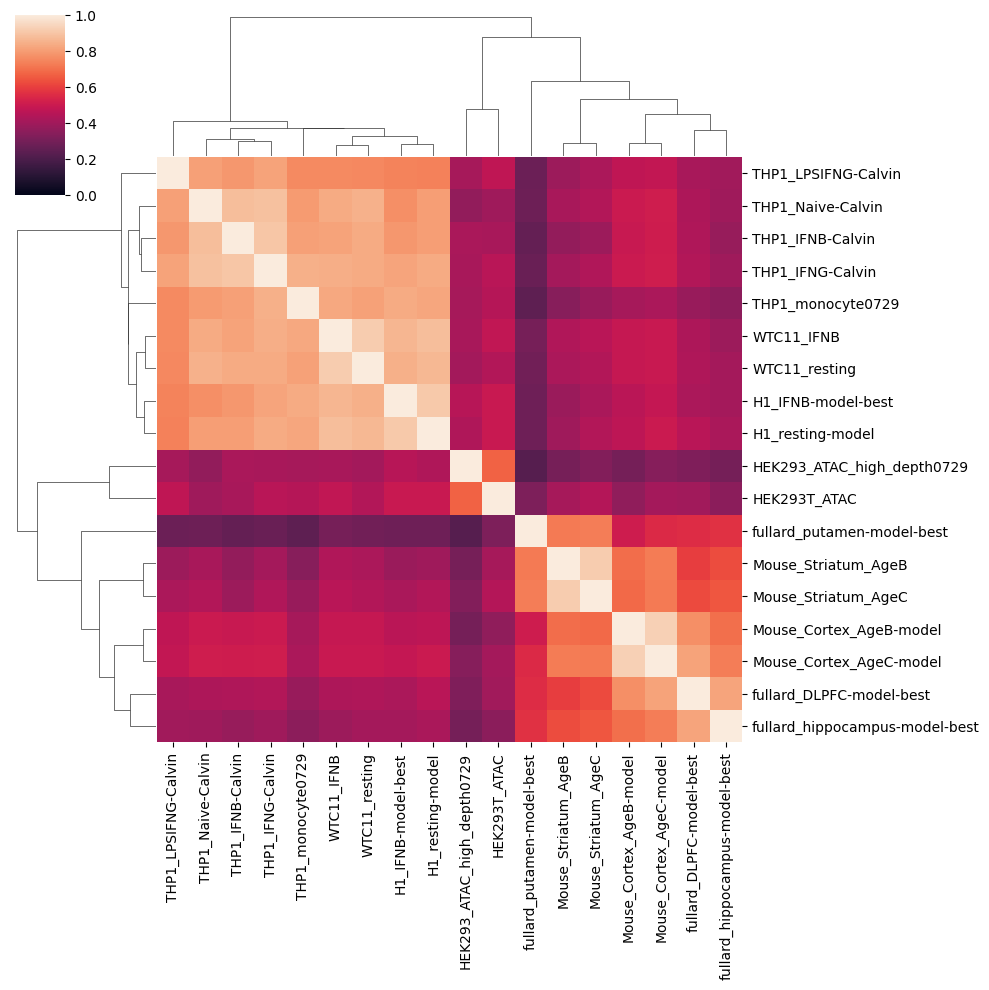

In [9]:
import seaborn as sns
sns.clustermap(all_pos_diff_unique.corr(),vmin=0,vmax=1)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from adjustText import adjust_text

def plot_scatter_with_outliers(df_cluster, 
                               x_cell, 
                               y_cell, 
                               x_label, 
                               y_label, 
                               title,
                               difference_threshold=2, 
                               save_file=None,
                               logfc_outlier_file=None,
                               ylim=None):
    """
    Plot scatter with regression line and highlight outliers. 
    Also compute p-values based on residuals, do FDR correction,
    and print highest p-value and highest FDR among outliers.
    
    Parameters:
    ----------
    - df_cluster : pd.DataFrame
        Data containing x_cell, y_cell, and 'rsid_protein_coding_gene'.
    - x_cell, y_cell : str
        Column names for x and y variables.
    - x_label, y_label : str
        Axis labels.
    - title : str
        Plot title.
    - difference_threshold : float
        Threshold in std. deviations for labeling outliers.
    - save_file : str or None
        If provided, path to save the figure.
    - logfc_outlier_file : str or None
        If provided, CSV file containing logFC outliers (index matches df_cluster index).
    - ylim : tuple or None
        If provided, sets the y-axis limits (min, max).
    """

    # --------------------- 1) Fit Linear Regression ---------------------
    x = df_cluster[x_cell].values.reshape(-1, 1)
    y = df_cluster[y_cell].values
    model = LinearRegression()
    model.fit(x, y)
    y_pred = model.predict(x)

    # ------------------------- 2) Print R^2 ----------------------------
    r2_builtin = model.score(x, y)
    r2_manual = r2_score(y, y_pred)
    print(f"R^2 (model.score): {r2_builtin:.4f}")
    print(f"R^2 (r2_score):    {r2_manual:.4f}")

    # -------------------- 3) Calculate Residuals -----------------------
    residuals = y - y_pred
    df_cluster['Residual'] = residuals

    # ----------------- 4) Label Outliers by Threshold ------------------
    threshold = difference_threshold * np.std(residuals)
    outliers = np.abs(residuals) > threshold
    df_cluster['Outlier'] = outliers

    # ------------------- 5) Compute p-values & FDR ---------------------
    # Assuming residuals ~ Normal(0, sigma), we do a two-sided test:
    #    z = residual / std(residual)
    #    p_value = 2 * (1 - Phi(|z|))
    std_res = residuals.std(ddof=1)
    z_scores = residuals / std_res
    p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))

    # Apply FDR correction for the entire set of p-values
    reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')

    df_cluster['p_value'] = p_values
    df_cluster['FDR'] = pvals_corrected

    # Print the highest p-value and FDR among outliers
    highest_p_value_outliers = df_cluster.loc[df_cluster['Outlier'], 'p_value'].max()
    highest_fdr_outliers = df_cluster.loc[df_cluster['Outlier'], 'FDR'].max()
    print(f"Highest p-value among outliers: {highest_p_value_outliers:.4e}")
    print(f"Highest FDR among outliers:    {highest_fdr_outliers:.4e}")

    # --------------------- 6) Prepare Color Coding ----------------------
    # Highlight all threshold-based outliers in green,
    # then highlight those that also appear in logfc_outlier_file in orange.
    df_cluster['Color'] = np.where(df_cluster['Outlier'], 'green', 'lightgrey')

    # -------------- 7) Load logFC outliers (if provided) ---------------
    if logfc_outlier_file is not None:
        df_logfc_outlier = pd.read_csv(logfc_outlier_file, index_col=0)
    else:
        df_logfc_outlier = pd.DataFrame()

    # Subset of green points (threshold-based outliers)
    green_points = df_cluster[df_cluster['Outlier']]

    # Among the threshold-based outliers, those also in logfc_outlier_file
    if not df_logfc_outlier.empty:
        red_points = green_points[green_points.index.isin(df_logfc_outlier.index)]
    else:
        red_points = pd.DataFrame(columns=df_cluster.columns)

    # --------------------- 8) Plotting Section -------------------------
    plt.figure(figsize=(6, 6), dpi=300)
    plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.3)

    # Scatter all points
    plt.scatter(
        df_cluster[x_cell],
        df_cluster[y_cell],
        c=df_cluster['Color'],
        alpha=0.7,
        s=10,
        edgecolor='none'
    )

    # Plot regression line
    plt.plot(x, y_pred, color='blue', linewidth=2, label='Regression Line', alpha=0.3)

    # Highlight threshold-based outliers
    plt.scatter(
        green_points[x_cell],
        green_points[y_cell],
        color='green',
        label='Significant Accessibility Differences',
        s=15
    )

    # Highlight those that are also in logfc_outlier_file
    if not red_points.empty:
        plt.scatter(
            red_points[x_cell],
            red_points[y_cell],
            color='orange',
            label='Significant Differences & log2(Fold Change)',
            s=15
        )

    # Label outliers (green_points) by 'rsid_protein_coding_gene'
    texts = []
    for idx, row in green_points.iterrows():
        texts.append(
            plt.text(
                row[x_cell],
                row[y_cell] + 0.2,  # small vertical offset
                row['rsid_protein_coding_gene'],
                fontsize=8,
                color='black',
                ha='center',
                va='bottom'
            )
        )

    # Adjust labels to avoid overlaps
    adjust_text(
        texts,
        force_text=(0.05, 0.05),
        force_points=(0.1, 0.1)
    )

    # Finalize plot
    plt.xlabel(x_label, fontsize=10)
    plt.ylabel(y_label, fontsize=10)
    plt.title(title, fontsize=15, weight='bold')
    plt.legend(loc='upper left', fontsize=8)
    if ylim is not None:
        plt.ylim(ylim)
    plt.tight_layout()

    # Save plot if save_file is given
    if save_file:
        plt.savefig(save_file, dpi=300, bbox_inches='tight')
        print(f"Plot saved to {save_file}")

    plt.show()


In [3]:
import pandas as pd
df_cluster = pd.read_csv( ('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/normalized_majorminor_diff.csv'),index_col=0)

Highest p-value among outliers: 1.5631e-03
Highest FDR among outliers:    9.3632e-02
Plot saved to scatter_plot_LPSIFNGvsNaive.pdf


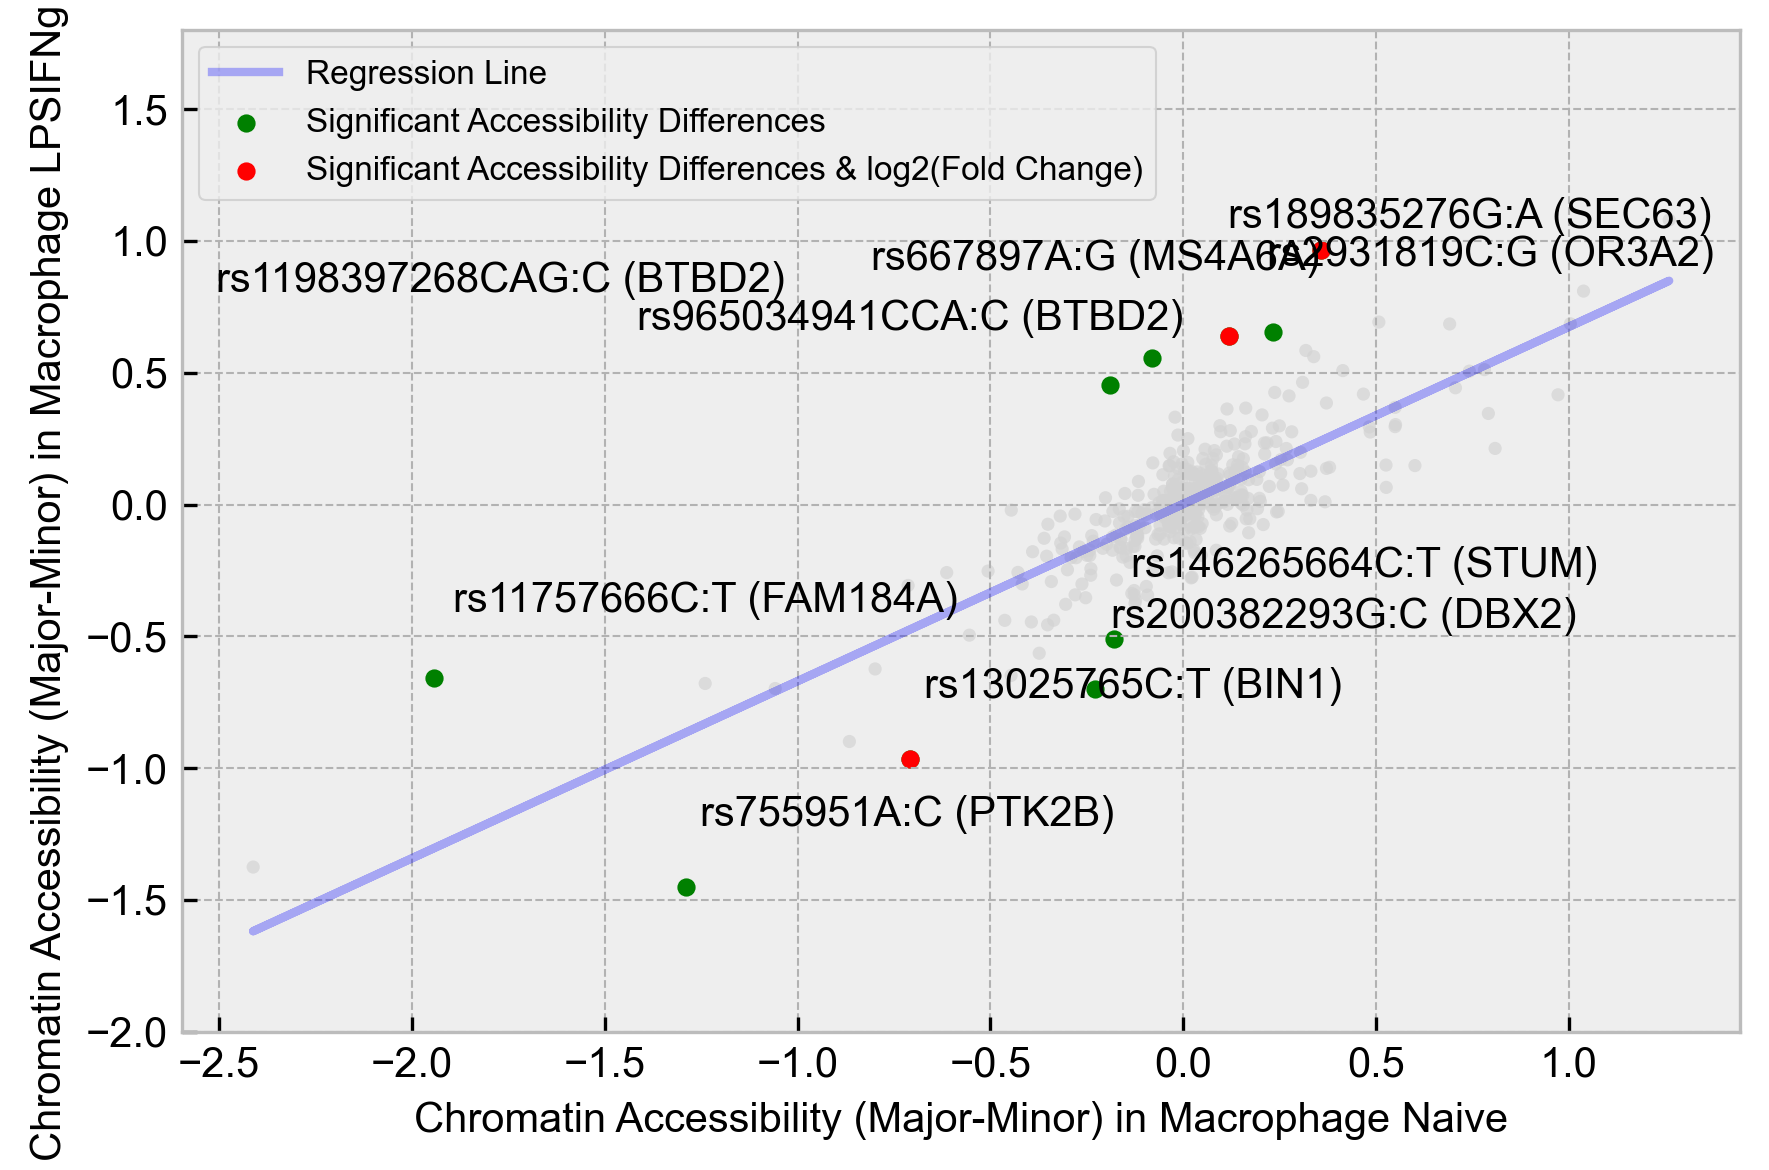

In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
import matplotlib as mpl
mpl.rcParams.update({
    'pdf.fonttype': 42,   # embed TrueType fonts → Illustrator‑editable
    'ps.fonttype': 42,    # same for EPS/PS
    'svg.fonttype': 'none',   # keep text as <text> elements in SVG
    'font.family': 'Arial',   # use a font installed on your machine
})
# For p-value & FDR calculations
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# ----------------------------------------------------------------------
# 1) Read and prepare data
# ----------------------------------------------------------------------
parsed_columns = pd.read_csv("20241202_model_type_sample_sheet.csv")
df_cluster = pd.read_csv(
    "/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/normalized_majorminor_diff.csv",
    index_col=0
)

df_diff = pd.read_csv(
    "/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/THP1_LPSIFNGvsNaive_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv",
    header=None
)
df_diff = df_diff.groupby(df_diff.index // 2).mean()
df_cluster['THP1_Macrophage_LPSIFNGvsNaive'] = (
    np.array(df_diff[0][0:855]) - np.array(df_diff[0][855:])
)

df_haploreg = pd.read_csv(
    "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv",
    index_col=0
)
df_haploreg['rsid_protein_coding_gene'] = (
    df_haploreg['rsID'] + df_haploreg['Major'] + ":" +
    df_haploreg['Minor'] + ' (' + df_haploreg['closest_protein_coding_gene_TSS'] + ')'
)
df_cluster = pd.merge(
    df_cluster,
    df_haploreg[['rsid_protein_coding_gene','rsID']],
    left_index=True, right_index=True
).drop_duplicates('rsID')

df_diff_sig_index = df_cluster[
    abs(df_cluster['THP1_Macrophage_LPSIFNGvsNaive']) >= 0.05
].index

data = df_cluster[parsed_columns['OriginalColumn'].tolist()]
data = data.reset_index()
data = data.rename(columns={'index': 'snp_id'})

# ----------------------------------------------------------------------
# 2) Define variables for plotting
# ----------------------------------------------------------------------
x_cell = 'THP1_Macrophage_Naive'
y_cell = 'THP1_Macrophage_LPSIFNG'
x_label = 'Chromatin Accessibility (Major-Minor) in Macrophage Naive'
y_label = 'Chromatin Accessibility (Major-Minor) in Macrophage LPSIFNg 4 hrs'
title = 'THP1 Macrophage LPSIFNg vs Naive'
difference_threshold = 3
save_file = 'scatter_plot_LPSIFNGvsNaive.pdf'  # Optional

# ----------------------------------------------------------------------
# 3) Fit a linear model and calculate residuals
# ----------------------------------------------------------------------
x = df_cluster[x_cell].values.reshape(-1, 1)
y = df_cluster[y_cell].values

model = LinearRegression()
model.fit(x, y)

y_pred = model.predict(x)
residuals = y - y_pred
df_cluster['Residual'] = residuals

# ----------------------------------------------------------------------
# 4) Identify outliers based on residual threshold
# ----------------------------------------------------------------------
threshold = difference_threshold * np.std(residuals)
outliers = np.abs(residuals) > threshold
df_cluster['Outlier'] = outliers

# ----------------------------------------------------------------------
# 5) Compute two-sided p-values and FDR for all points
#    Assuming residuals ~ Normal(0, sigma)
# ----------------------------------------------------------------------
std_res = np.std(residuals, ddof=1)
z_scores = residuals / std_res
p_values = 2 * (1 - norm.cdf(np.abs(z_scores)))  # Two-sided

reject, pvals_corrected, _, _ = multipletests(p_values, alpha=0.05, method='fdr_bh')
df_cluster['p_value'] = p_values
df_cluster['FDR'] = pvals_corrected

# ----------------------------------------------------------------------
# 6) Print highest p-value and highest FDR among outliers
# ----------------------------------------------------------------------
highest_p_value_outliers = df_cluster.loc[df_cluster['Outlier'], 'p_value'].max()
highest_fdr_outliers = df_cluster.loc[df_cluster['Outlier'], 'FDR'].max()
print(f"Highest p-value among outliers: {highest_p_value_outliers:.4e}")
print(f"Highest FDR among outliers:    {highest_fdr_outliers:.4e}")

# ----------------------------------------------------------------------
# 7) Update color coding (grey for non-outliers, green for outliers)
# ----------------------------------------------------------------------
df_cluster['Color'] = np.where(df_cluster['Outlier'], 'green', 'lightgrey')

# ----------------------------------------------------------------------
# 8) Plot the scatter with outliers in green and significant ones in red
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 4), dpi=300)
#plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.3)

# Scatter plot of all points
plt.scatter(
    df_cluster[x_cell],
    df_cluster[y_cell],
    c=df_cluster['Color'],
    alpha=0.7,
    s=10,
    edgecolor='none'
)

# Regression line
plt.plot(x, y_pred, color='blue', linewidth=2, label='Regression Line', alpha=0.3)

# Outliers (green)
green_points = df_cluster[df_cluster['Outlier']]
plt.scatter(
    green_points[x_cell],
    green_points[y_cell],
    color='green',
    label='Significant Accessibility Differences',
    s=15
)

# Among the outliers, highlight those that are also in df_diff_sig_index (red)
red_points = green_points[green_points.index.isin(df_diff_sig_index)]
plt.scatter(
    red_points[x_cell],
    red_points[y_cell],
    color='red',
    label='Significant Accessibility Differences & log2(Fold Change)',
    s=15
)

# Label outliers
texts = []
for idx, row in green_points.iterrows():
    texts.append(
        plt.text(
            row[x_cell],
            row[y_cell] + 0.2,
            row['rsid_protein_coding_gene'],
            fontsize=10,
            color='black',
            ha='center',
            va='bottom'
        )
    )

adjust_text(
    texts,
    force_text=(0.05, 0.0),
    force_points=(0.1, 0.1)
)

plt.xlabel(x_label, fontsize=10)
plt.ylabel(y_label, fontsize=10)
#plt.title(title, fontsize=15, weight='bold')
plt.ylim(-2, 1.8)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()

if save_file:
    # Uncomment the line below if you actually want to save the figure
    plt.savefig(save_file, dpi=300, bbox_inches='tight')
    print(f"Plot saved to {save_file}")

plt.show()


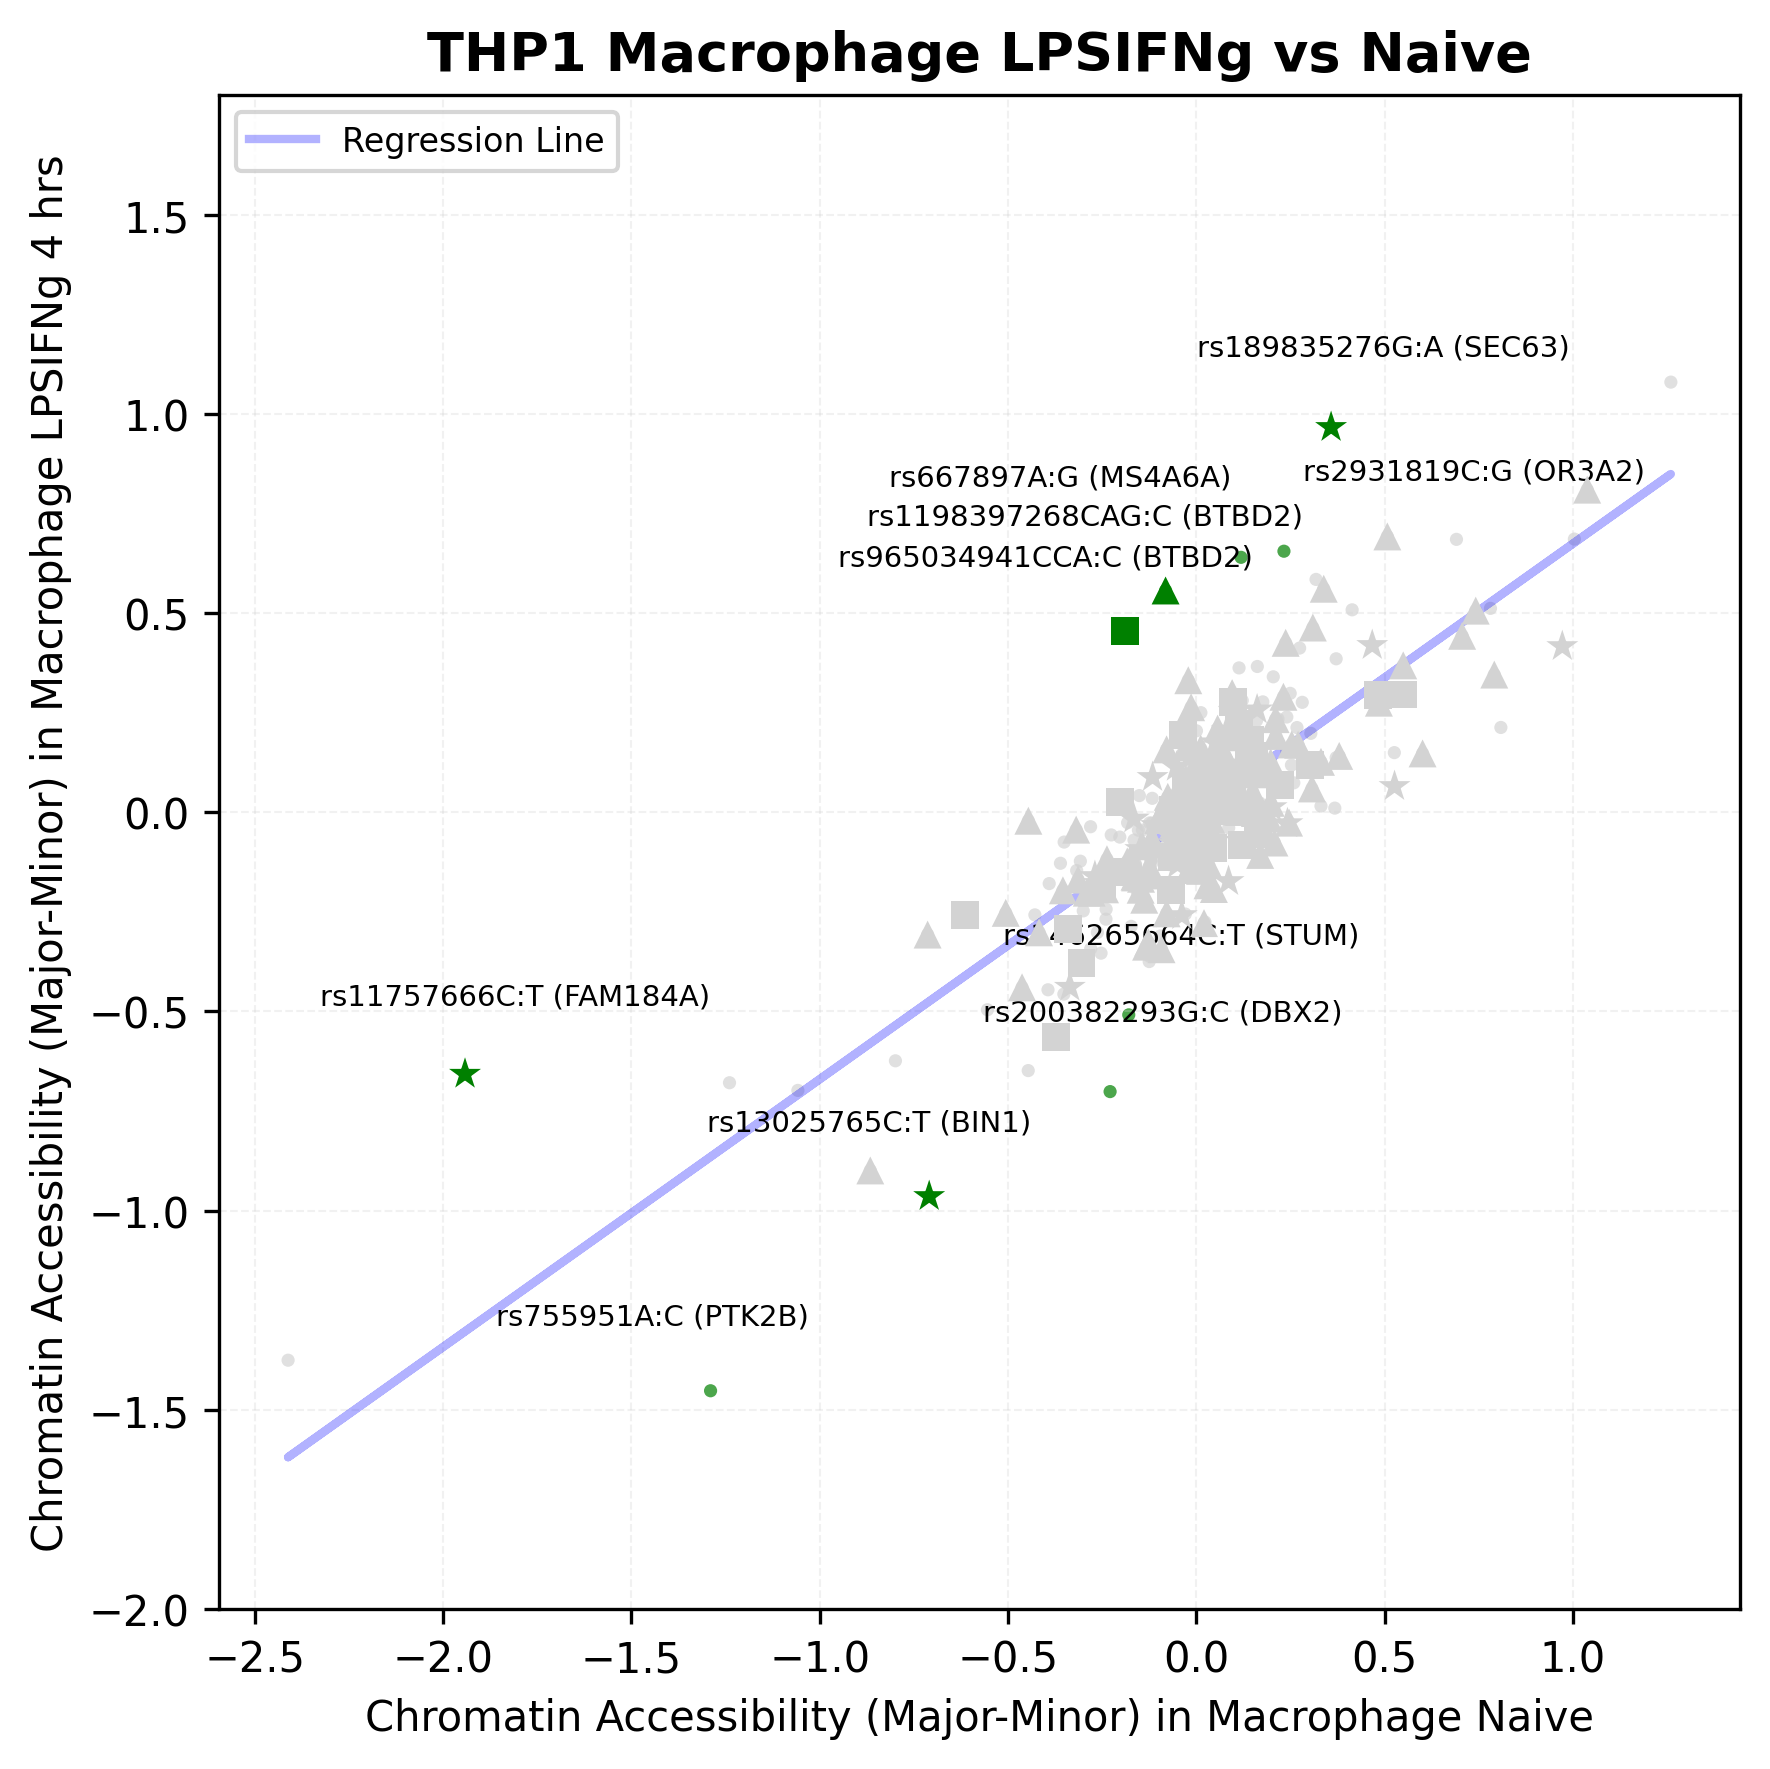

In [13]:
#!/usr/bin/env python
# -*- coding: utf-8 -*-

# ──────────────────────────────────────────────────────────────
#  Imports
# ──────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from adjustText import adjust_text
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

# ──────────────────────────────────────────────────────────────
# 0  Load MPRA result tables (for the shape markers)  ← NEW
# ──────────────────────────────────────────────────────────────
df_mpra_thp1 = pd.read_csv(
    '/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/'
    '20240813_allele_only/20240813_comparative_THP1Macrophage_alleleOnly.csv',
    index_col=0
).query('fdr <= 0.05 and abs(logFC) >= 0.0')

df_mpra_brain = pd.read_csv(
    '/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/'
    '20240813_allele_only/20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv',
    index_col=0
).query('fdr <= 0.05 and abs(logFC) >= 0.0')

# ──────────────────────────────────────────────────────────────
# 1  Read & prepare chromatin-difference data  (unchanged)
# ──────────────────────────────────────────────────────────────
parsed_columns = pd.read_csv("20241202_model_type_sample_sheet.csv")
df_cluster = pd.read_csv(
    "/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/"
    "normalized_majorminor_diff.csv",
    index_col=0
)

df_diff = pd.read_csv(
    "/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/"
    "THP1_LPSIFNGvsNaive_20240826_MPRA_500bp_SNPandControl_500bpbarcodes_one.csv",
    header=None
)
df_diff = df_diff.groupby(df_diff.index // 2).mean()
df_cluster['THP1_Macrophage_LPSIFNGvsNaive'] = (
    np.array(df_diff[0][0:855]) - np.array(df_diff[0][855:])
)

df_haploreg = pd.read_csv(
    "indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv",
    index_col=0
)
df_haploreg['rsid_protein_coding_gene'] = (
    df_haploreg['rsID'] + df_haploreg['Major'] + ":" +
    df_haploreg['Minor'] + ' (' + df_haploreg['closest_protein_coding_gene_TSS'] + ')'
)
df_cluster = pd.merge(
    df_cluster,
    df_haploreg[['rsid_protein_coding_gene', 'rsID']],
    left_index=True, right_index=True
).drop_duplicates('rsID')

df_diff_sig_index = df_cluster[
    abs(df_cluster['THP1_Macrophage_LPSIFNGvsNaive']) >= 0.05
].index

data = df_cluster[parsed_columns['OriginalColumn'].tolist()].reset_index()
data = data.rename(columns={'index': 'snp_id'})

# ──────────────────────────────────────────────────────────────
# 2  Plotting variables (unchanged)
# ──────────────────────────────────────────────────────────────
x_cell = 'THP1_Macrophage_Naive'
y_cell = 'THP1_Macrophage_LPSIFNG'
x_label = 'Chromatin Accessibility (Major-Minor) in Macrophage Naive'
y_label = 'Chromatin Accessibility (Major-Minor) in Macrophage LPSIFNg 4 hrs'
title = 'THP1 Macrophage LPSIFNg vs Naive'
difference_threshold = 3
save_file = 'scatter_plot_LPSIFNGvsNaive.pdf'

# ──────────────────────────────────────────────────────────────
# 3  Linear model & residuals (unchanged)
# ──────────────────────────────────────────────────────────────
x = df_cluster[x_cell].values.reshape(-1, 1)
y = df_cluster[y_cell].values
mdl = LinearRegression().fit(x, y)
y_pred = mdl.predict(x)
residuals = y - y_pred
df_cluster['Residual'] = residuals

# ──────────────────────────────────────────────────────────────
# 4  Outlier detection (unchanged)
# ──────────────────────────────────────────────────────────────
threshold = difference_threshold * np.std(residuals)
df_cluster['Outlier'] = np.abs(residuals) > threshold

# ──────────────────────────────────────────────────────────────
# 5  p-value & FDR (unchanged)
# ──────────────────────────────────────────────────────────────
std_res = np.std(residuals, ddof=1)
p_vals = 2 * (1 - norm.cdf(np.abs(residuals / std_res)))
_, fdr_vals, _, _ = multipletests(p_vals, alpha=0.05, method='fdr_bh')
df_cluster['p_value'] = p_vals
df_cluster['FDR'] = fdr_vals

# ──────────────────────────────────────────────────────────────
# 6  Colours
# ──────────────────────────────────────────────────────────────
df_cluster['Color'] = np.where(df_cluster['Outlier'], 'green', 'lightgrey')

# ──────────────────────────────────────────────────────────────
# 7  Scatter plot
# ──────────────────────────────────────────────────────────────
plt.figure(figsize=(6, 6), dpi=300)
plt.grid(color='lightgray', linestyle='--', linewidth=0.5, alpha=0.3)

# base layer — all SNPs
plt.scatter(
    df_cluster[x_cell], df_cluster[y_cell],
    c=df_cluster['Color'], s=10, alpha=0.7, edgecolor='none'
)

# regression line
plt.plot(x, y_pred, color='blue', lw=2, alpha=0.3, label='Regression Line')

# ----------------------------------------------------------------------
# 7A  SHAPE OVERLAY  ← NEW
# ----------------------------------------------------------------------
# indices for each MPRA category
sig_thp1   = df_mpra_thp1.index.difference(df_mpra_brain.index)
sig_brain  = df_mpra_brain.index.difference(df_mpra_thp1.index)
sig_both   = df_mpra_thp1.index.intersection(df_mpra_brain.index)

# draw each set once, preserving the colour already assigned
def _draw_shapes(idx_set, marker, size=45):
    subset = df_cluster.loc[idx_set.intersection(df_cluster.index)]
    if subset.empty:
        return
    plt.scatter(
        subset[x_cell], subset[y_cell],
        marker=marker, s=size,
        c=subset['Color'],  # keeps grey vs green
        edgecolor='none', alpha=1, zorder=5, label='_nolegend_'
    )

_draw_shapes(sig_thp1,  '^')   # THP-1 only
_draw_shapes(sig_brain, 's')   # Brain only
_draw_shapes(sig_both,  '*', 65)  # Both sets (bigger star)

# ----------------------------------------------------------------------
# 8  Outlier labels (unchanged)
# ----------------------------------------------------------------------
texts = []
for idx, row in df_cluster[df_cluster['Outlier']].iterrows():
    texts.append(
        plt.text(
            row[x_cell], row[y_cell] + 0.15,
            row['rsid_protein_coding_gene'],
            fontsize=7, color='black', ha='center', va='bottom'
        )
    )
adjust_text(texts, force_text=(0.05, 0.0), force_points=(0.1, 0.1))

plt.xlabel(x_label, fontsize=10)
plt.ylabel(y_label, fontsize=10)
plt.title(title, fontsize=13, weight='bold')
plt.ylim(-2, 1.8)
plt.legend(loc='upper left', fontsize=8)
plt.tight_layout()

# Uncomment to save
# plt.savefig(save_file, dpi=300, bbox_inches='tight')
plt.show()


R^2 (model.score): 0.7893
R^2 (r2_score):    0.7893
Highest p-value among outliers: 2.2773e-03
Highest FDR among outliers:    1.5157e-01
Plot saved to scatter_plot_IFNGvsNaive.pdf


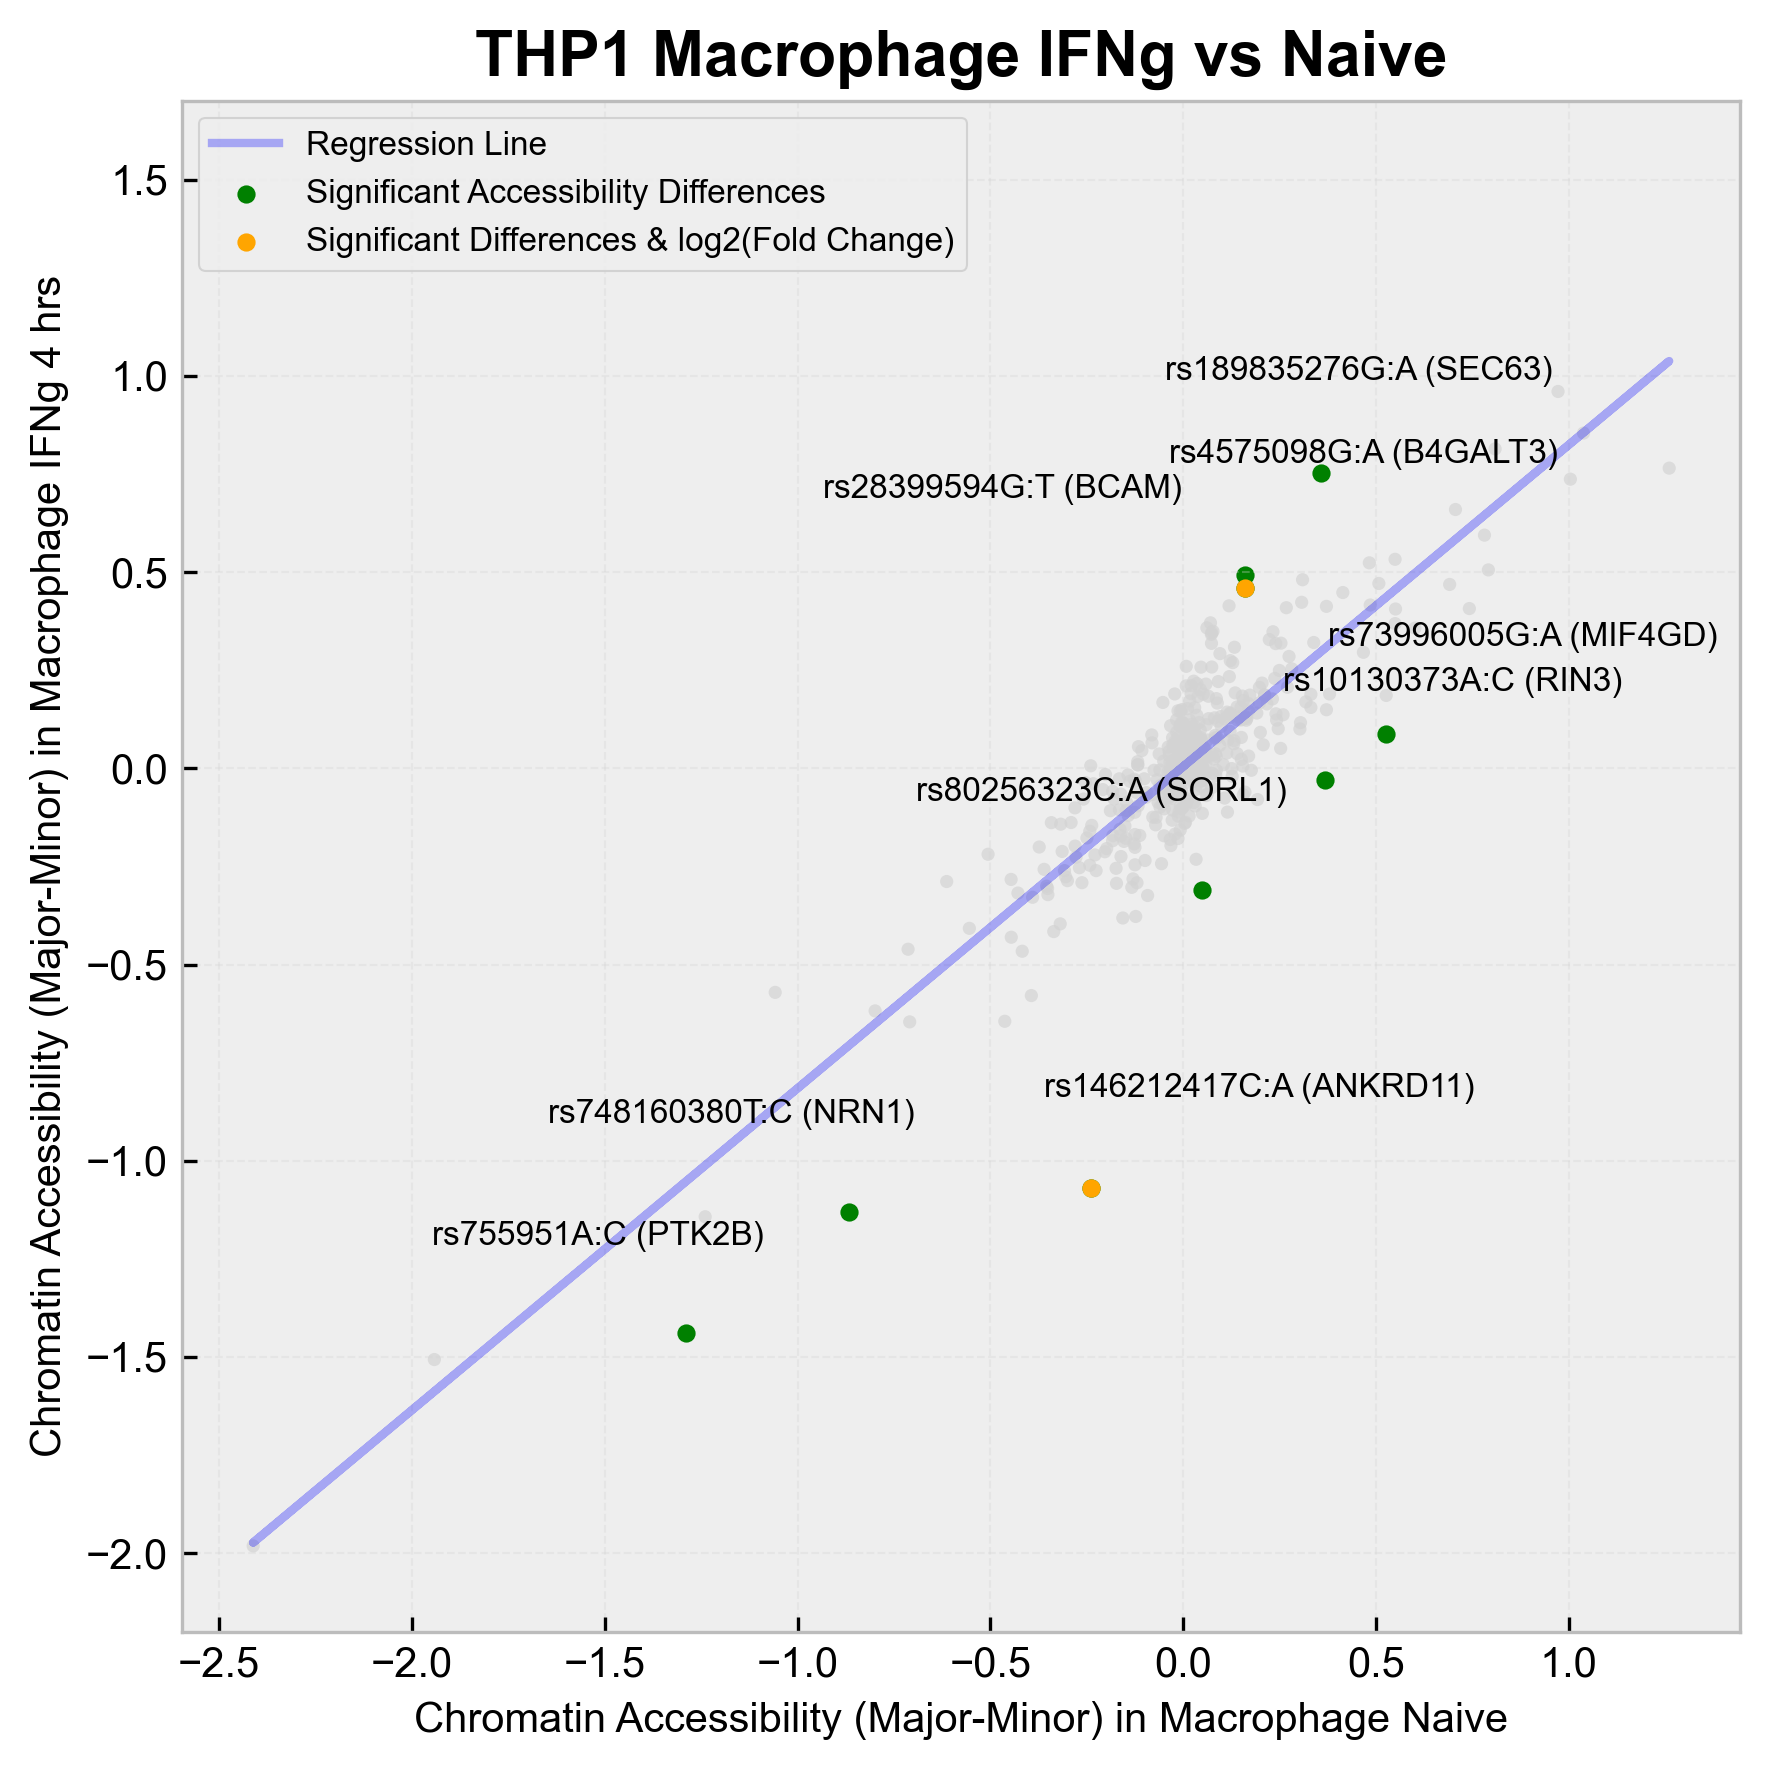

In [63]:
plot_scatter_with_outliers(
    df_cluster=df_cluster,
    x_cell='THP1_Macrophage_Naive',
    y_cell='THP1_Macrophage_IFNG',
    x_label='Chromatin Accessibility (Major-Minor) in Macrophage Naive',
    y_label='Chromatin Accessibility (Major-Minor) in Macrophage IFNg 4 hrs',
    title='THP1 Macrophage IFNg vs Naive',
    difference_threshold = 3,
    save_file='scatter_plot_IFNGvsNaive.pdf',  # Optional: Provide a path to save the plot
    logfc_outlier_file =  '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/IFNG_VS_Naive_logFC_outlier.csv',
    ylim=(-2.2,1.7)
)

R^2 (model.score): 0.7781
R^2 (r2_score):    0.7781
Highest p-value among outliers: 2.4037e-03
Highest FDR among outliers:    1.1998e-01
Plot saved to scatter_plot_IFNBvsNaive.pdf


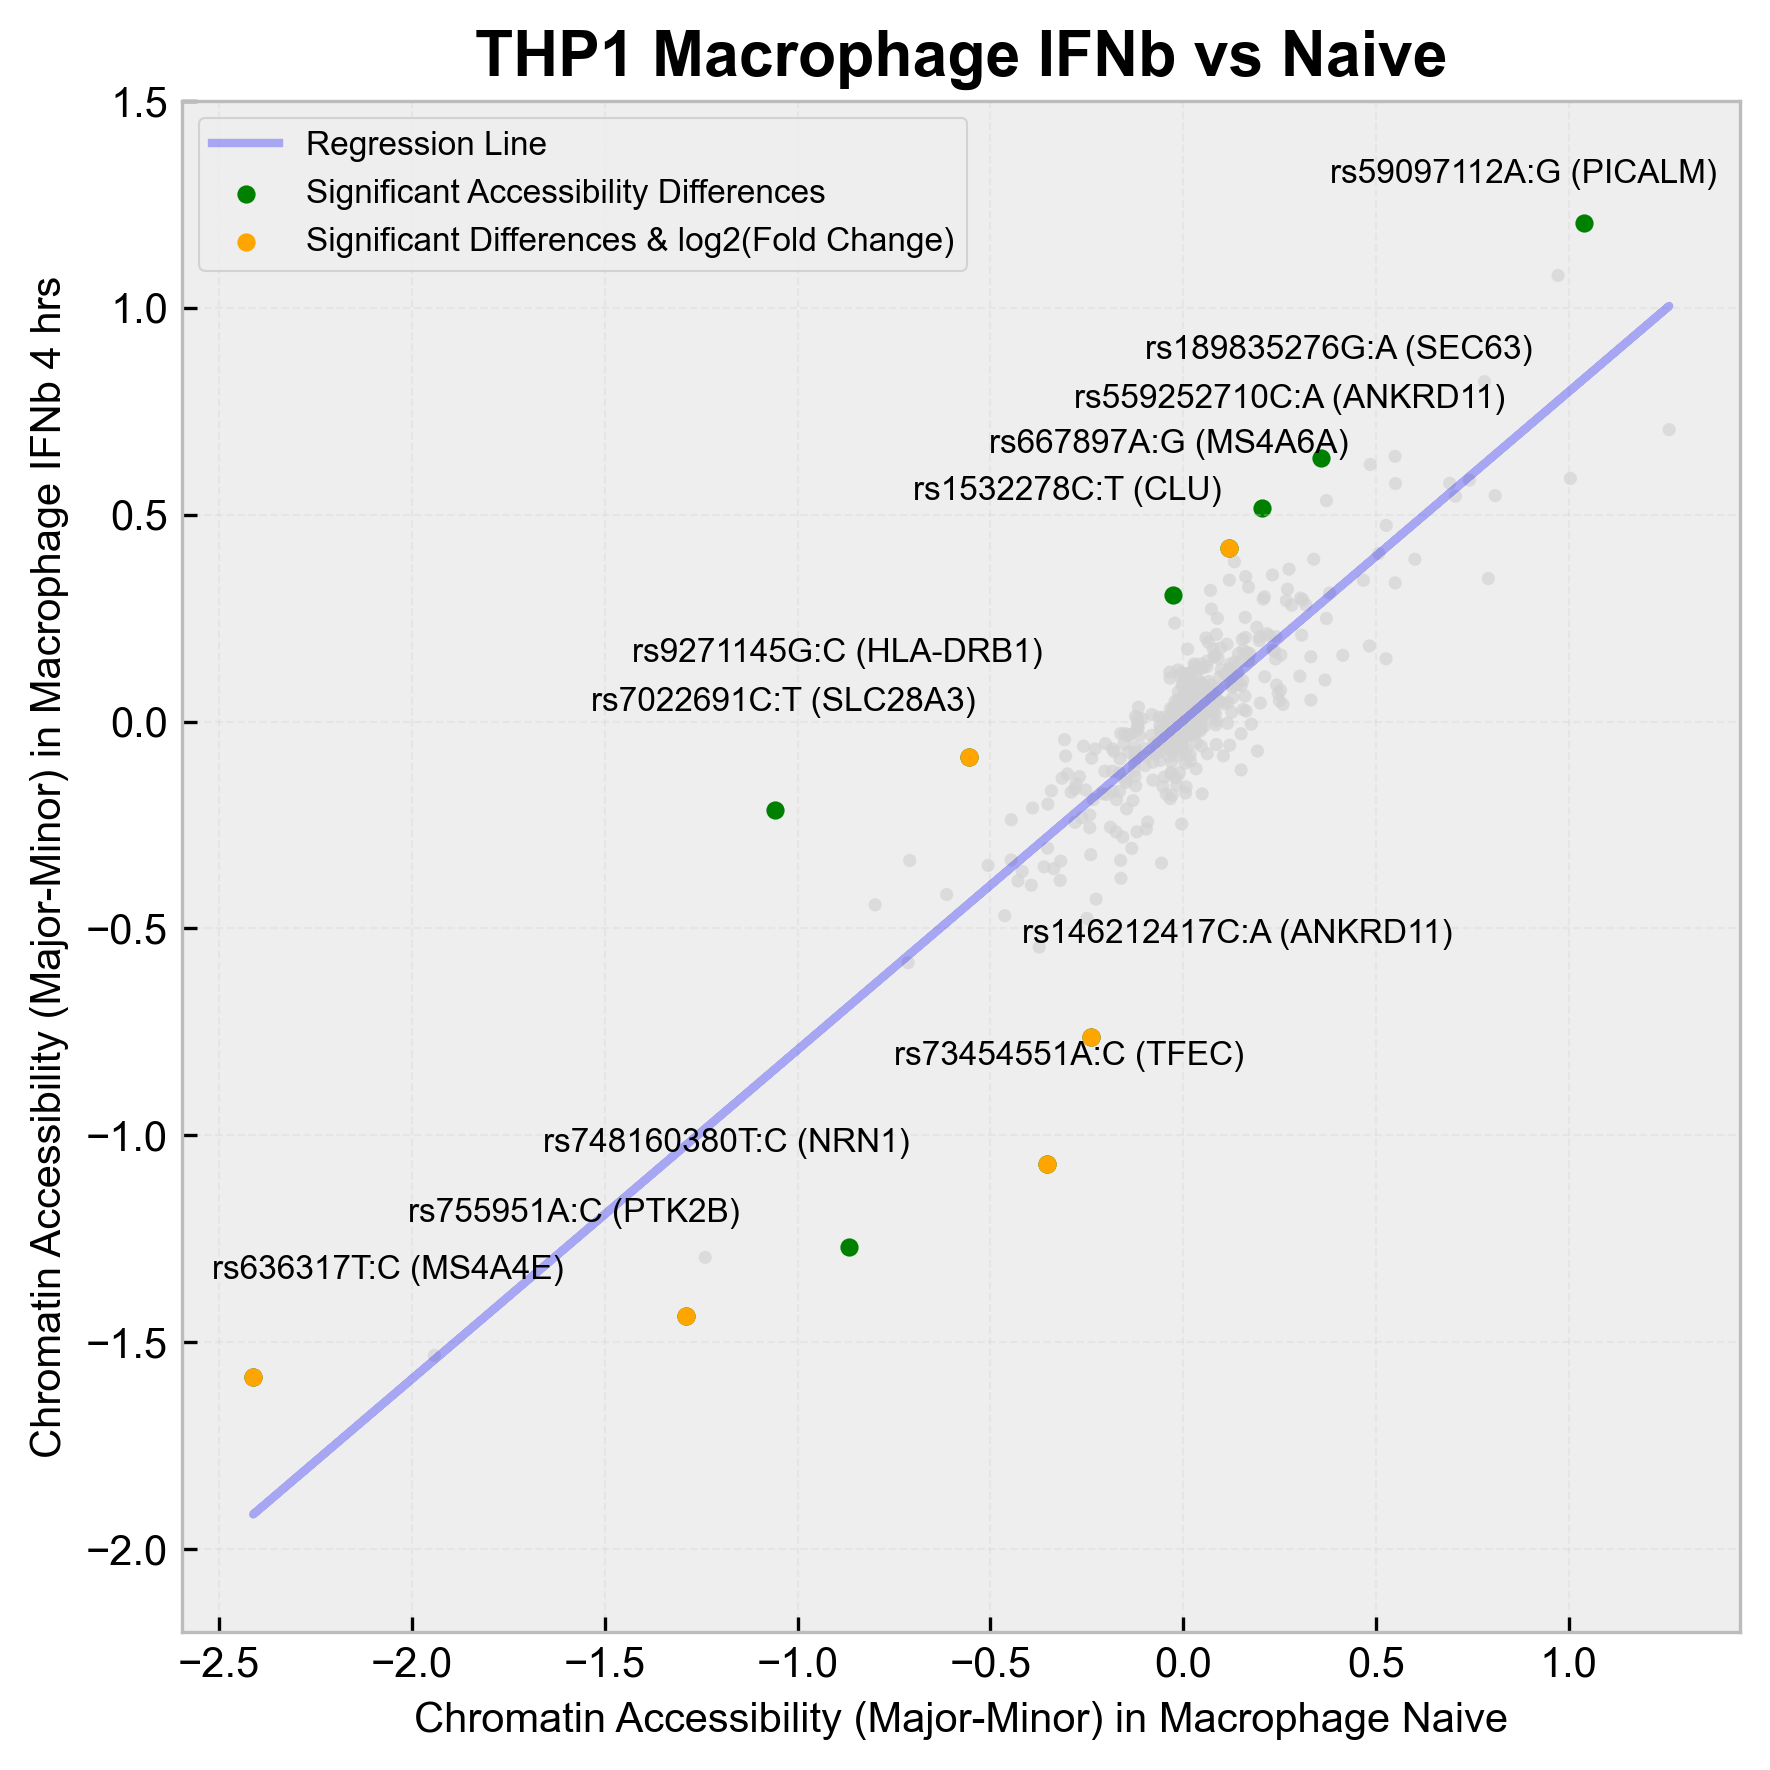

In [64]:
plot_scatter_with_outliers(
    df_cluster=df_cluster,
    x_cell='THP1_Macrophage_Naive',
    y_cell='THP1_Macrophage_IFNB',
    x_label='Chromatin Accessibility (Major-Minor) in Macrophage Naive',
    y_label='Chromatin Accessibility (Major-Minor) in Macrophage IFNb 4 hrs',
    title='THP1 Macrophage IFNb vs Naive',
    difference_threshold = 3,
    save_file='scatter_plot_IFNBvsNaive.pdf',  # Optional: Provide a path to save the plot
    logfc_outlier_file =  '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/IFNB_VS_Naive_logFC_outlier.csv',
    ylim=(-2.2,1.5) 
)

In [45]:

plot_scatter_with_outliers(
    df_cluster=df_cluster,
    x_cell='Human_DLPFC_Neuron',
    y_cell='Human_Putamen_Neuron',
    x_label='Chromatin Accessibility (Major-Minor) in Huma DLPFC Neuron',
    y_label='Chromatin Accessibility (Major-Minor) in Human Putamen Neuron',
    title='Striatum vs Cortex',
    difference_threshold = 3,
    save_file='scatter_plot_StriatumvsCortex.pdf',
    logfc_outlier_file =  '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/DLPFC_VS_Putamen_logFC_outlier.csv',
    ylim=(-3,2.4)     # Optional: Provide a path to save the plot
)

R^2 (model.score): 0.3077
R^2 (r2_score):    0.3077
Highest p-value among outliers: 1.5433e-03
Highest FDR among outliers:    9.2441e-02


FileNotFoundError: [Errno 2] No such file or directory: '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/DLPFC_VS_Putamen_logFC_outlier.csv'

R^2 (model.score): 0.5405
R^2 (r2_score):    0.5405
Highest p-value among outliers: 2.2212e-03
Highest FDR among outliers:    9.5035e-02
Plot saved to scatter_plot_StriatumvsCortex.pdf


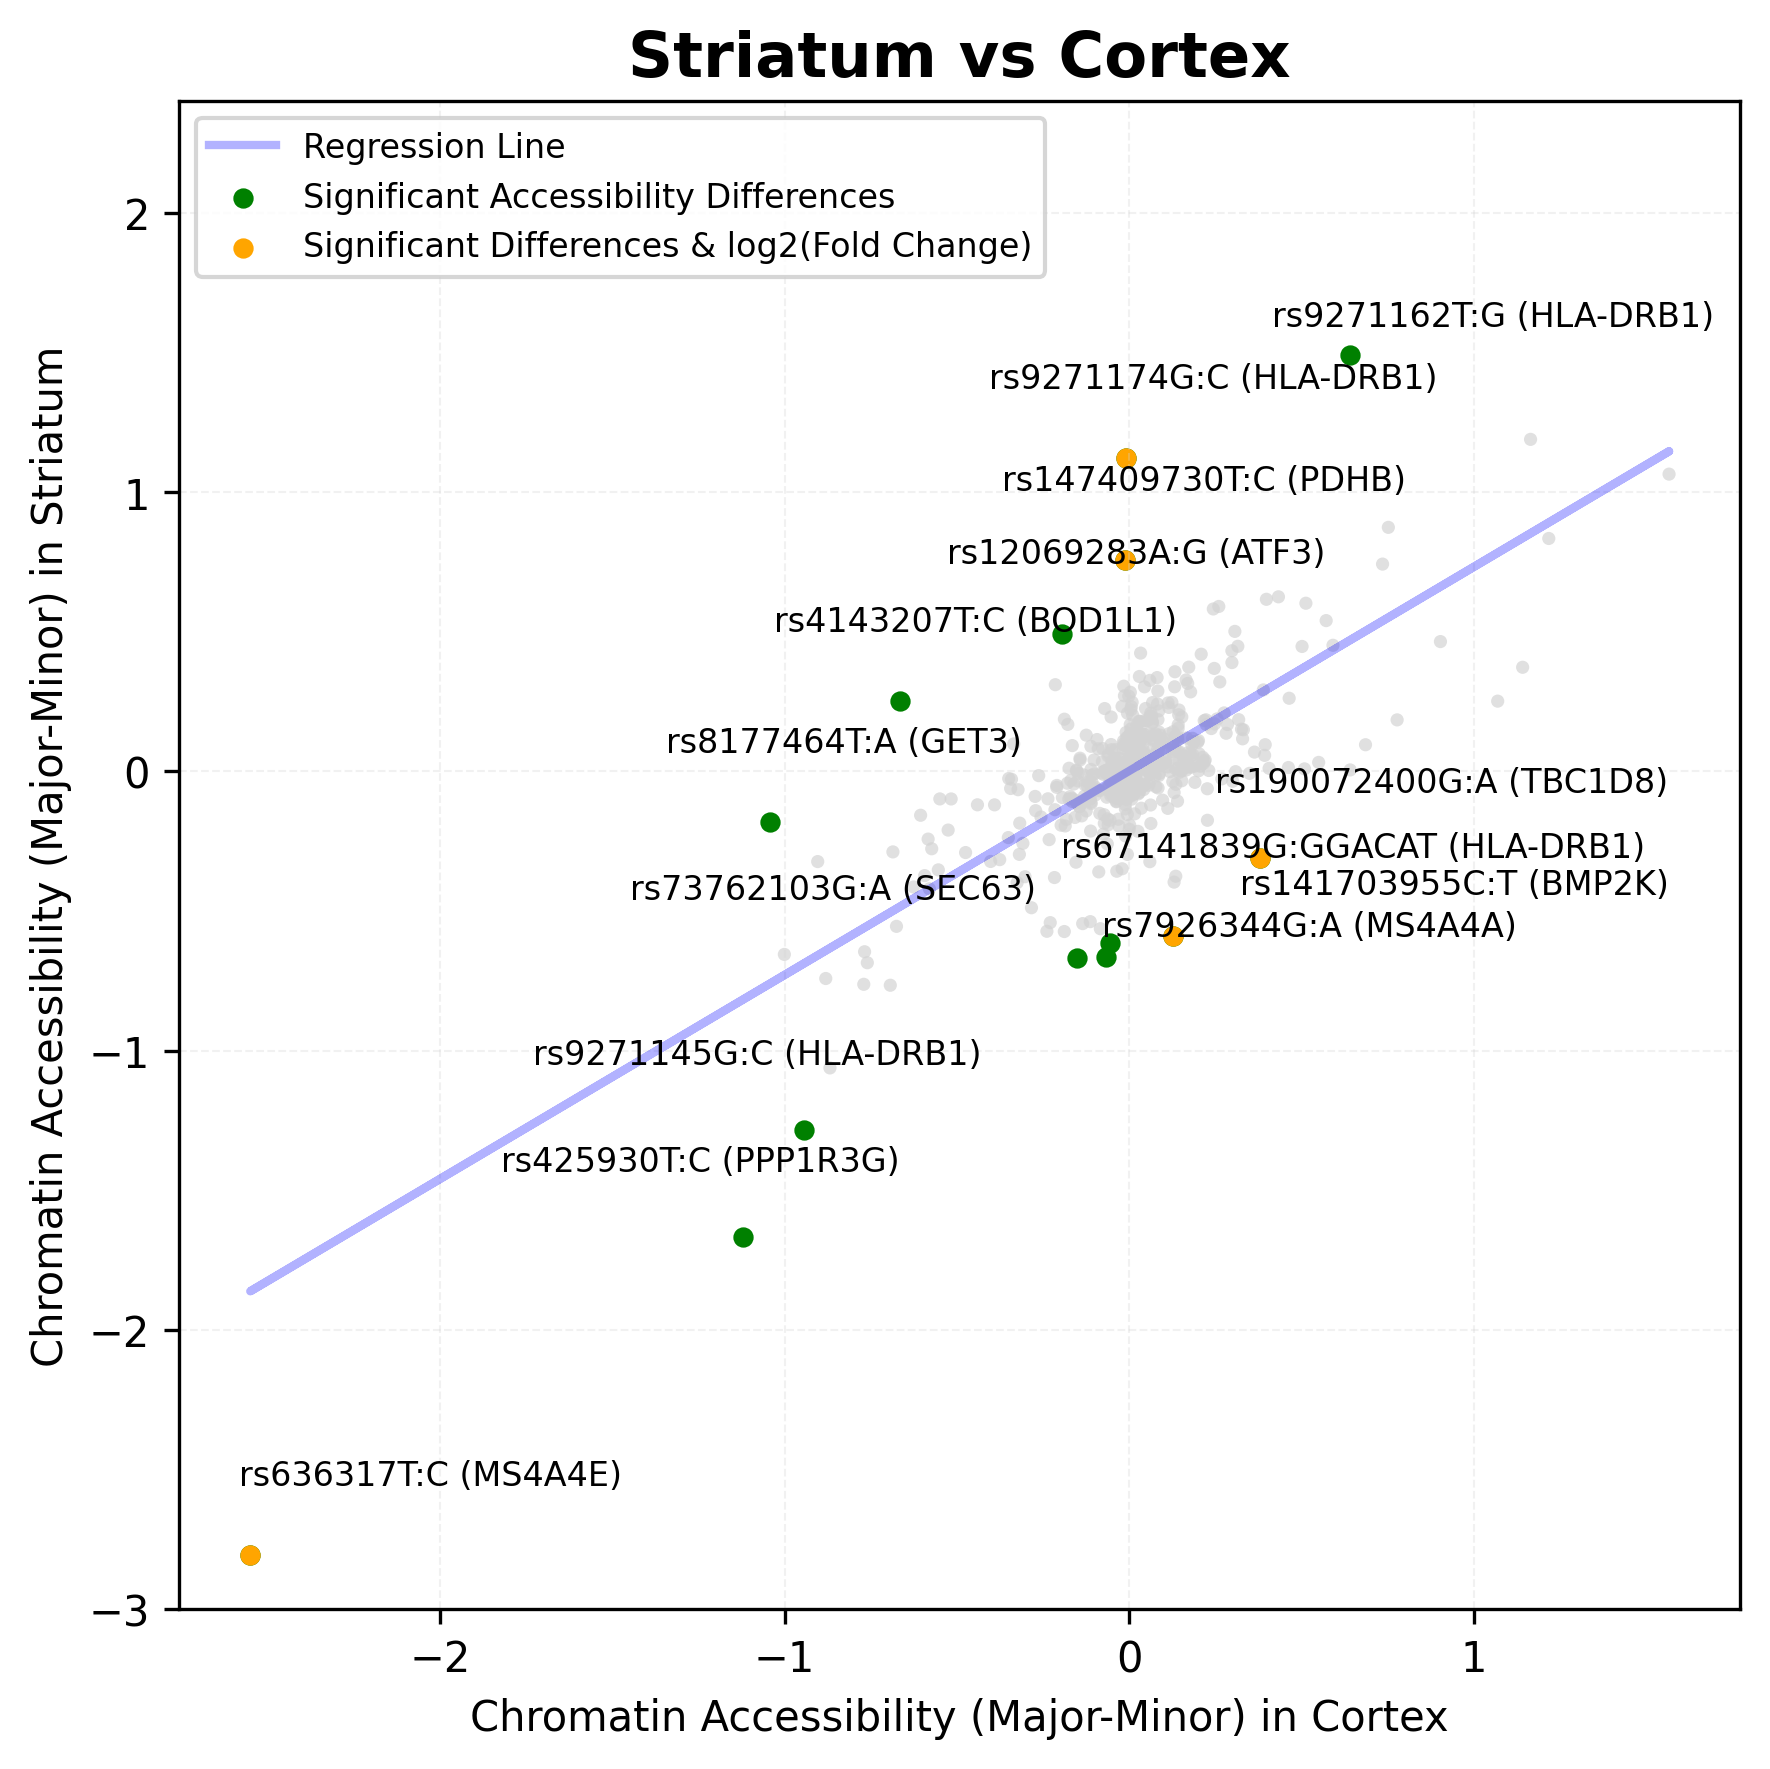

In [16]:
df_cluster_brain = pd.DataFrame()
df_cluster_brain['Mouse_Cortex'] = (df_cluster['Mouse_Cortex_AgeB'] + df_cluster['Mouse_Cortex_AgeC'])/2
df_cluster_brain['Mouse_Striatum'] = (df_cluster['Mouse_Striatum_AgeB'] + df_cluster['Mouse_Striatum_AgeC'])/2
df_cluster_brain['rsid_protein_coding_gene'] = df_cluster['rsid_protein_coding_gene']
plot_scatter_with_outliers(
    df_cluster=df_cluster_brain,
    x_cell='Mouse_Cortex',
    y_cell='Mouse_Striatum',
    x_label='Chromatin Accessibility (Major-Minor) in Cortex',
    y_label='Chromatin Accessibility (Major-Minor) in Striatum',
    title='Striatum vs Cortex',
    difference_threshold = 3,
    save_file='scatter_plot_StriatumvsCortex.pdf',
    logfc_outlier_file =  '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/Striatum_VS_Cortex_logFC_outlier.csv',
    ylim=(-3,2.4)     # Optional: Provide a path to save the plot
)

In [ ]:
df_cluster.columns

Index(['Human_Putamen_Neuron', 'Human_DLPFC_Neuron',
       'Human_Hippocampus_Neuron', 'Mouse_Cortex_AgeB', 'Mouse_Cortex_AgeC',
       'Mouse_Striatum_AgeB', 'Mouse_Striatum_AgeC', 'THP1_Macrophage_Naive',
       'THP1_Macrophage_IFNB', 'THP1_Macrophage_IFNG',
       'THP1_Macrophage_LPSIFNG', 'iPSC_Microglia_IFNB',
       'hESC_Microglia_Naive', 'iPSC_Microglia_Naive', 'hESC_Microglia_IFNB',
       'rsid_protein_coding_gene', 'rsID'],
      dtype='object')

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


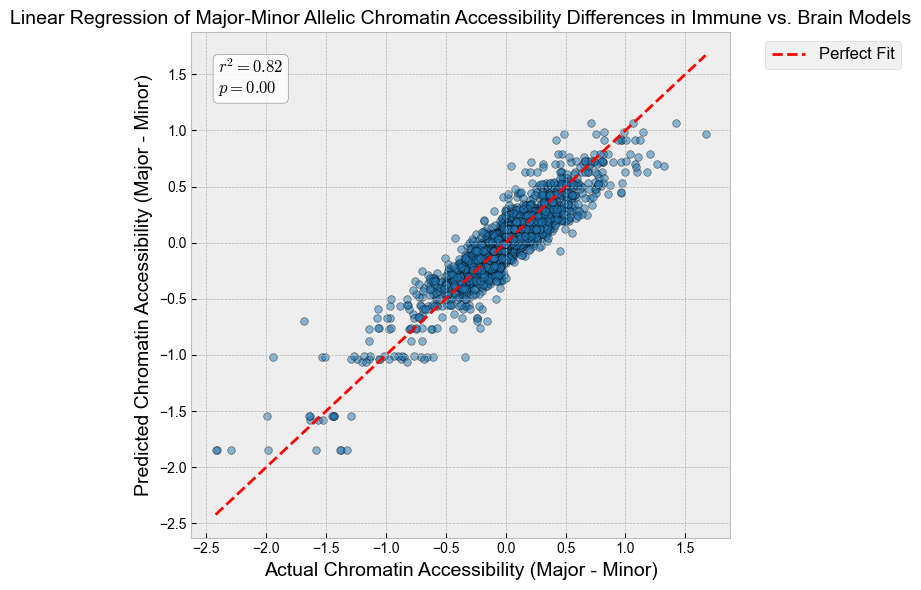

Overall R-squared: 0.8237390518544208


In [65]:
import pandas as pd
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import matplotlib as mpl
mpl.rcParams.update({
    'pdf.fonttype': 42,   # embed TrueType fonts → Illustrator‑editable
    'ps.fonttype': 42,    # same for EPS/PS
    'svg.fonttype': 'none',   # keep text as <text> elements in SVG
    'font.family': 'Arial',   # use a font installed on your machine
})

# Step 1: Reset the index of data to make 'snp_id' a column (assumed provided)
import pandas as pd
parsed_columns=pd.read_csv("20241202_model_type_sample_sheet.csv")
df_cluster = pd.read_csv( ('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/normalized_majorminor_diff.csv'),index_col=0)
df_haploreg = pd.read_csv('indexing/SNP_haploregannotatr_ATAC_tss_SNPFunction_spliceai_bayesianML_Bellenguez_TSS_20250103.csv',index_col=0)
df_haploreg['rsid_protein_coding_gene'] = df_haploreg['rsID']+df_haploreg['Major']+":"+df_haploreg['Minor']+' (' +df_haploreg['closest_protein_coding_gene_TSS']+')'

df_cluster = pd.merge(df_cluster,df_haploreg[['rsid_protein_coding_gene','rsID']],left_index=True,right_index=True).drop_duplicates('rsID')
data = df_cluster[parsed_columns['OriginalColumn'].tolist()]
data = data.reset_index()
data = data.rename(columns={'index': 'snp_id'})

# Step 4: Melt the data to long format
long_data = pd.melt(
    data,
    id_vars=['snp_id'],  # 'snp_id' is now a column
    var_name='OriginalColumn',  # The variable name after melting
    value_name='Major_Minor_Diff'  # The value name after melting
)

# Step 5: Merge long_data with parsed_columns on 'OriginalColumn'
long_data = long_data.merge(parsed_columns, on='OriginalColumn')

long_data = long_data[long_data['SubType'] == 'Human'].copy()
long_data['CellType'] = pd.Categorical(
    long_data['CellType'],
    categories=['Immune', 'Neuron']
)

predictions = []
results = []

for snp_id, snp_data in long_data.groupby('snp_id'):
    snp_data = snp_data.copy()
    model = smf.ols('Major_Minor_Diff ~ C(CellType)', data=snp_data).fit()
    snp_data['Predicted'] = model.predict(snp_data)
    predictions.append(snp_data)
    results.append({
        'SNP_ID': snp_id,
        'Coefficients': model.params,
        'PValues': model.pvalues,
    })
# Combine predictions into a single DataFrame
predicted_data = pd.concat(predictions)
####################################################
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

# Use a clean, publication-friendly style
plt.style.use('bmh')  # bmh style generally provides a neat look

fig, ax = plt.subplots(figsize=(8, 6))

# Create a scatter plot with improved markers:
# - s: marker size
# - alpha: transparency
# - edgecolors: outline color
# - facecolors: fill color (using a hex color for a nice blue)
ax.scatter(
    predicted_data['Major_Minor_Diff'],
    predicted_data['Predicted'],
    s=30, alpha=0.5, edgecolors='k', facecolors='#1f77b4',
    label=''
)

# Plot the perfect fit line
min_val = predicted_data['Major_Minor_Diff'].min()
max_val = predicted_data['Major_Minor_Diff'].max()
ax.plot(
    [min_val, max_val], [min_val, max_val],
    color='red', linestyle='--', lw=2, label='Perfect Fit'
)

# Calculate the Pearson correlation coefficient and p-value
r, p = pearsonr(predicted_data['Major_Minor_Diff'], predicted_data['Predicted'])
r2_value = r**2  # Compute r-squared

# Annotate the plot with r^2 and p-value
ax.text(
    0.05, 0.95, f'$r^2 = {r2_value:.2f}$\n$p = {p:.2f}$',
    transform=ax.transAxes, fontsize=12,
    verticalalignment='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray', alpha=0.8)
)

# Set axis labels and title with increased font sizes for clarity
ax.set_xlabel('Actual Chromatin Accessibility (Major - Minor)', fontsize=14)
ax.set_ylabel('Predicted Chromatin Accessibility (Major - Minor)', fontsize=14)
ax.set_title('Linear Regression of Major-Minor Allelic Chromatin Accessibility Differences in Immune vs. Brain Models', fontsize=14)

# Place the legend outside the plot to avoid overlapping the data points
ax.legend(fontsize=12, loc='upper left', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('major_minor_diff_regression.pdf', dpi=300, bbox_inches='tight')

plt.show()

#########################################################
# Step 9: Calculate and print R-squared score for all data
from statsmodels.stats.multitest import multipletests
overall_r2 = r2_score(predicted_data['Major_Minor_Diff'], predicted_data['Predicted'])
print(f"Overall R-squared: {overall_r2}")

celltype_pvalues = []
snp_ids = []
coefficients = []
for result in results:
    pvalue = result['PValues'].get('C(CellType)[T.Neuron]', None)
    if pvalue is not None:
        celltype_pvalues.append(pvalue)
        snp_ids.append(result['SNP_ID'])
        result['PValues'].get('C(CellType)[T.Neuron]', None)
        coefficients.append(result['Coefficients'].get('C(CellType)[T.Neuron]', None))


adjusted_pvalues = multipletests(celltype_pvalues, method='fdr_bh')[1]

# Create a DataFrame with the results
results_df = pd.DataFrame({
    'SNP_ID': snp_ids,
    'CellType_PValue': celltype_pvalues,
    'Adj_PValue': adjusted_pvalues,
    'Coefficient':coefficients
})

# Identify significant SNPs
significant_snps = results_df[results_df['Adj_PValue'] <= 0.05]
results_df['Significant'] = (results_df['Adj_PValue'] <= 0.05) & (abs(results_df['Coefficient']) >= 0.2)
import matplotlib.pyplot as plt
import numpy as np

# Calculate -log10 of adjusted p-values
results_df['neg_log10_Adj_PValue'] = -np.log10(results_df['Adj_PValue'])
results_df=results_df.set_index('SNP_ID')
results_df = pd.merge(results_df,df_haploreg[['rsid_protein_coding_gene']],left_index=True,right_index=True)

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp
'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


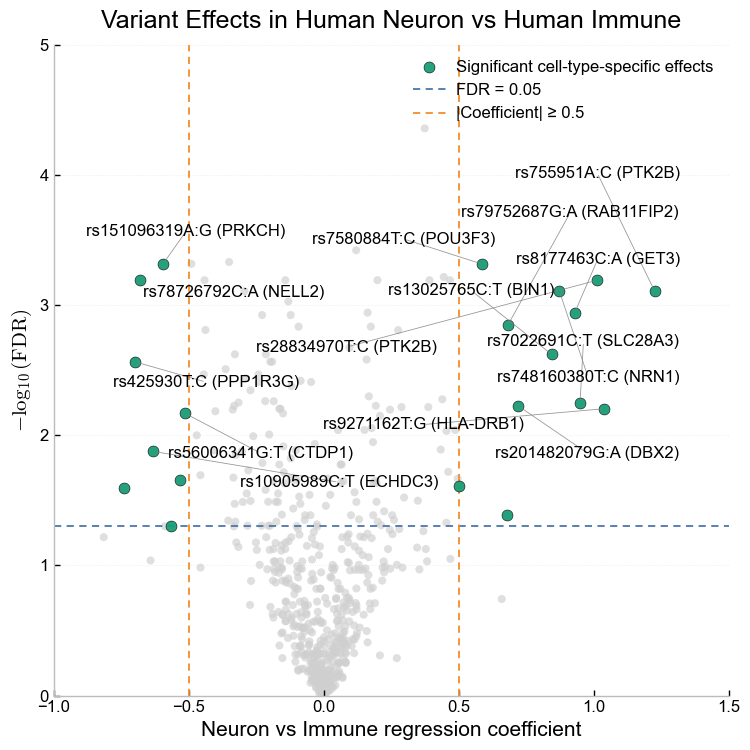

In [46]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from adjustText import adjust_text
import matplotlib as mpl

mpl.rcParams.update({
    'pdf.fonttype': 42,
    'ps.fonttype': 42,
    'svg.fonttype': 'none',
    'font.family': 'Arial',
})

df = results_df.copy()

coef_thresh = 0.5
fdr_thresh = 0.05
top_n_labels = 15

# clean
df = df.replace([np.inf, -np.inf], np.nan).dropna(
    subset=["Coefficient", "neg_log10_Adj_PValue", "Adj_PValue"]
).copy()

# significance
df["is_significant"] = (
    (df["Adj_PValue"] <= fdr_thresh) &
    (df["Coefficient"].abs() >= coef_thresh)
)
significant = df[df["is_significant"]].copy()

# choose labels: prioritize strongest significance, then effect size
label_df = significant.sort_values(
    by=["neg_log10_Adj_PValue", "Coefficient"],
    ascending=[False, False]
).head(top_n_labels).copy()

# dynamic symmetric x-range
xmax = np.ceil(df["Coefficient"].abs().max() * 10) / 10
xmax = max(1.0, xmax)
ymax = np.ceil(df["neg_log10_Adj_PValue"].max())
ymax = max(6.0, ymax)

fig, ax = plt.subplots(figsize=(8*0.95, 8*0.95))

# transparent background
fig.patch.set_alpha(0)
ax.set_facecolor("none")

# all points
ax.scatter(
    df["Coefficient"],
    df["neg_log10_Adj_PValue"],
    s=34,
    c="#CFCFCF",
    alpha=0.65,
    edgecolors="none",
    rasterized=True,
    zorder=1
)

# significant points
ax.scatter(
    significant["Coefficient"],
    significant["neg_log10_Adj_PValue"],
    s=62,
    c="#1B9E77",
    alpha=0.95,
    edgecolors="black",
    linewidths=0.4,
    label="Significant cell-type-specific effects",
    zorder=3
)

# threshold lines
ax.axhline(
    -np.log10(fdr_thresh),
    color="#4C78A8",
    linestyle=(0, (4, 3)),
    linewidth=1.3,
    label="FDR = 0.05",
    zorder=2
)
ax.axvline(
    -coef_thresh,
    color="#F28E2B",
    linestyle=(0, (4, 3)),
    linewidth=1.3,
    label=f"|Coefficient| ≥ {coef_thresh}",
    zorder=2
)
ax.axvline(
    coef_thresh,
    color="#F28E2B",
    linestyle=(0, (4, 3)),
    linewidth=1.3,
    zorder=2
)

# labels
texts = []
if "rsid_protein_coding_gene" in df.columns and len(label_df) > 0:
    for _, row in label_df.iterrows():
        txt = ax.text(
            row["Coefficient"],
            row["neg_log10_Adj_PValue"],
            row["rsid_protein_coding_gene"],
            fontsize=12,
            color="black",
            ha="left",
            va="bottom",
            zorder=4
        )
        texts.append(txt)

    adjust_text(
        texts,
        ax=ax,
        arrowprops=dict(
            arrowstyle="-",
            color="gray",
            lw=0.6,
            alpha=0.8
        ),
        expand=(1.05, 1.15),
        force_text=(0.8, 1.0),
        force_static=(0.3, 0.3),
        lim=300
    )

# axes styling
ax.set_title(
    "Variant Effects in Human Neuron vs Human Immune",
    fontsize=18,
    pad=12
)
ax.set_xlabel(
    "Neuron vs Immune regression coefficient",
    fontsize=15
)
ax.set_ylabel(
    r"$-\log_{10}(\mathrm{FDR})$",
    fontsize=15
)

ax.set_xlim(-1, 1.5)
ax.set_ylim(0, 5)

ax.tick_params(axis='both', which='major', labelsize=12, length=4, width=1)

# lighter spines
for spine in ["top", "right"]:
    ax.spines[spine].set_visible(False)
for spine in ["left", "bottom"]:
    ax.spines[spine].set_linewidth(1.0)

# very subtle horizontal guide only
ax.grid(False)
ax.yaxis.grid(True, linestyle=":", linewidth=0.6, alpha=0.25)
ax.xaxis.grid(False)

# legend
ax.legend(
    frameon=False,
    fontsize=12,
    loc="upper right",
    handletextpad=0.6
)

plt.tight_layout()

# transparent export
plt.savefig(
    "volcano_plot_HumanNeuron_vs_HumanImmune.pdf",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)
plt.savefig(
    "volcano_plot_HumanNeuron_vs_HumanImmune.png",
    dpi=300,
    bbox_inches="tight",
    transparent=True
)

plt.show()

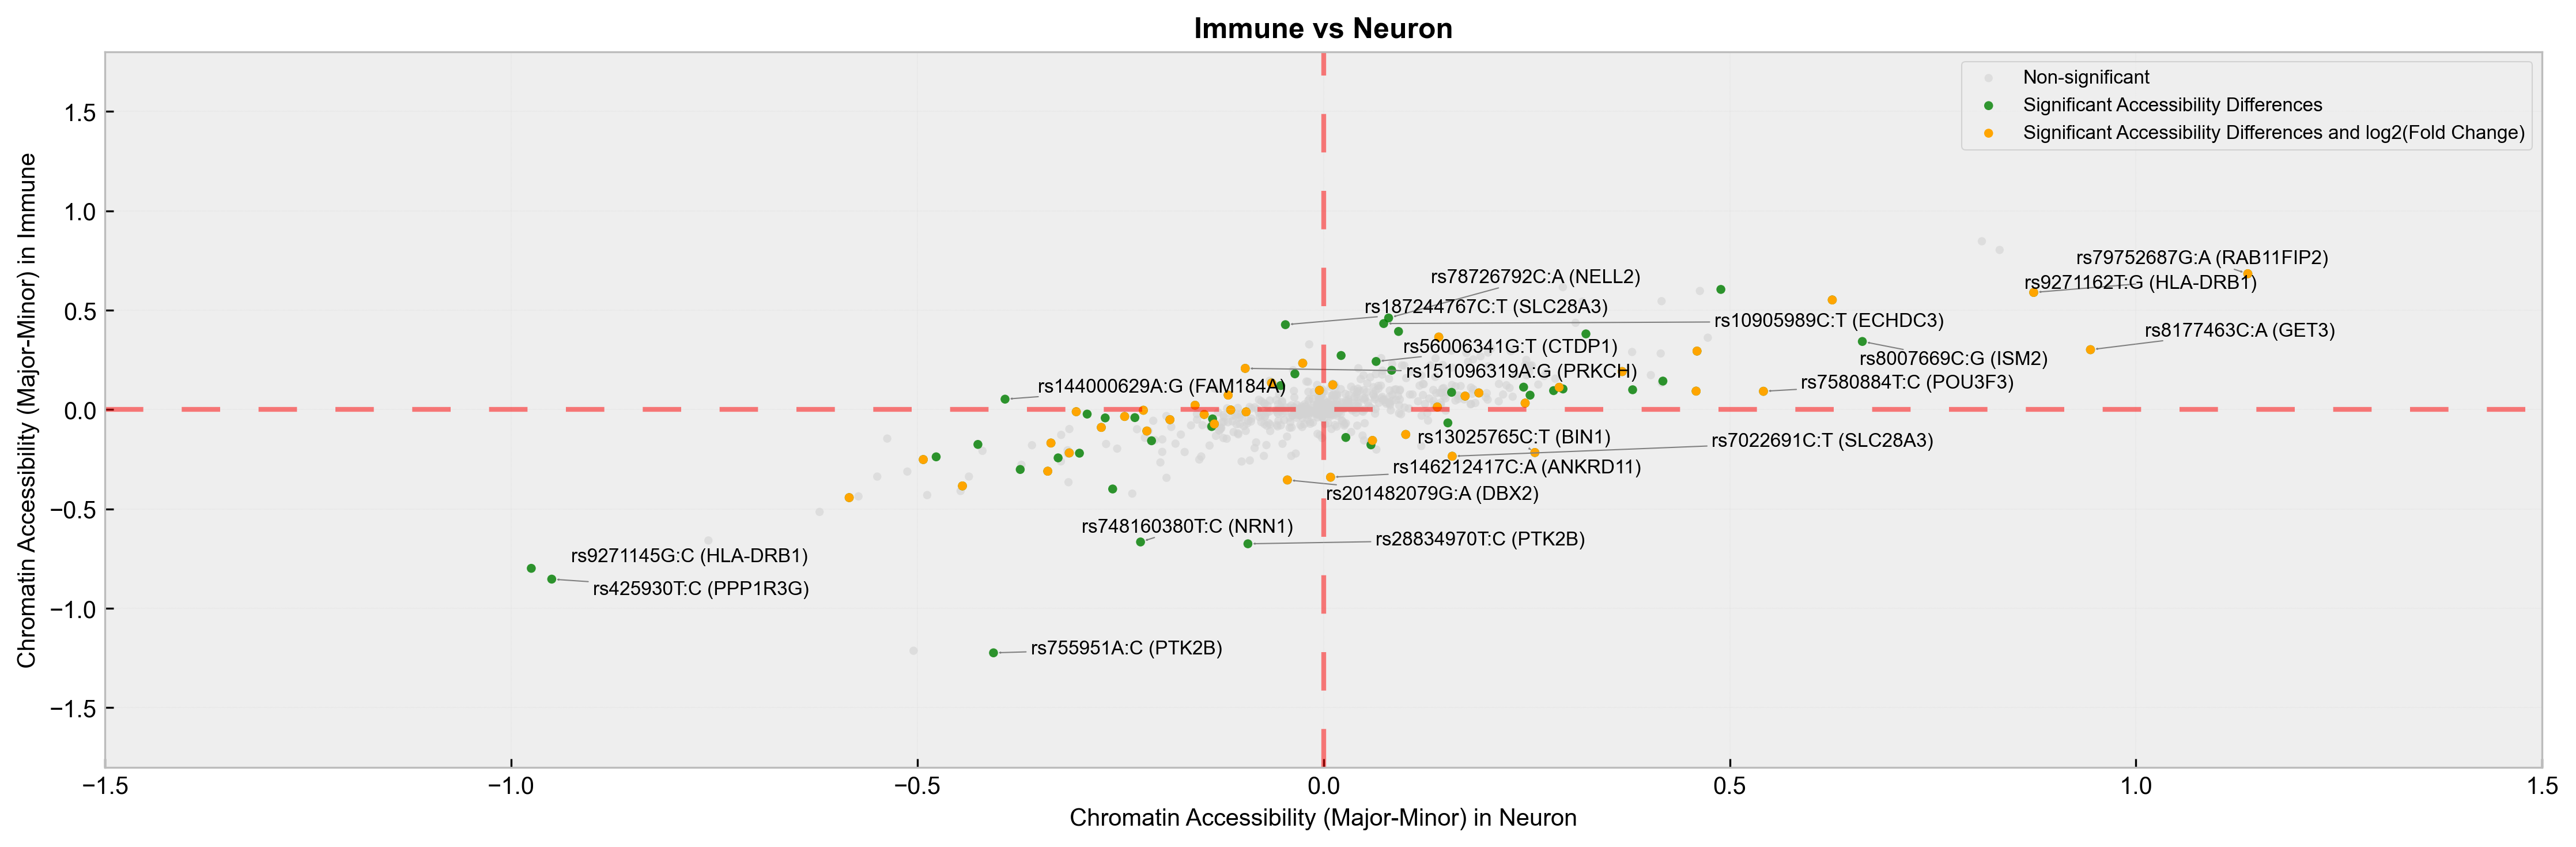

In [47]:
from adjustText import adjust_text
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
df_cluster = pd.read_csv( ('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/normalized_majorminor_diff.csv'),index_col=0)

df_cluster = pd.merge(df_cluster,df_haploreg[['rsid_protein_coding_gene','rsID']],left_index=True,right_index=True).drop_duplicates('rsID')
# Merge df_cluster with results_df to include adjusted p-values and significance
df_merged = df_cluster.merge(
    results_df[['Adj_PValue', 'Significant']],
    left_index=True, right_index=True
)
df_merged[df_merged['Significant']].to_csv('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/immune_brain_normalized_diff_significant.csv')
df_normalized_logfc_immune_brain = pd.read_csv("/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/immune_brain_normalized_logfc_significant.csv",index_col=0)
df_normalized_logfc_immune_brain_significant = df_normalized_logfc_immune_brain[df_normalized_logfc_immune_brain['Adj_PValue']<=0.05]
df_normalized_logfc_immune_brain_significant.head()
significant_points_rsid = df_merged[df_merged['Significant']]['rsid_protein_coding_gene']
significant_overlap = significant_points_rsid[significant_points_rsid.isin(df_normalized_logfc_immune_brain_significant['rsid_protein_coding_gene'])]
significant_overlap.to_csv('/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/immune_brain_significant_overlap.csv')
# Highlight significant SNPs
significant_points_index = df_merged[df_merged['Significant']].index

# Calculate mean values for plotting
x_mean = df_merged.iloc[:, 0:4].mean(axis=1)
y_mean = df_merged.iloc[:, 4:10].mean(axis=1)

# Create a scatter plot
plt.figure(figsize=(15, 5), dpi=300)

# Plot non-significant SNPs
plt.scatter(
    x_mean,
    y_mean,
    alpha=0.6, c='lightgrey', label='Non-significant', edgecolor='none', s=12
)

# Plot significant SNPs
plt.scatter(
    x_mean[significant_points_index],
    y_mean[significant_points_index],
    alpha=0.8, c='green', label='Significant Accessibility Differences', edgecolor='none', s=14
)
# Plot significant SNPs
plt.scatter(
    x_mean[significant_overlap.index],
    y_mean[significant_overlap.index],
    alpha=1, c='orange', label='Significant Accessibility Differences and log2(Fold Change)', edgecolor='none', s=14
)

# Identify extreme points
#extreme_x = x_mean[significant_overlap.index].abs().nlargest(5).index
#extreme_y = y_mean[significant_overlap.index].abs().nlargest(5).index
extreme_x = x_mean[significant.index].abs().index
extreme_y = y_mean[significant.index].abs().index

# Annotate extreme points
texts = []
for idx in extreme_x:
    texts.append(plt.text(x_mean[idx], y_mean[idx], df_merged.loc[idx]["rsid_protein_coding_gene"], fontsize=8, color='black'))
for idx in extreme_y:
    if idx not in extreme_x:
        texts.append(plt.text(x_mean[idx], y_mean[idx], df_merged.loc[idx]["rsid_protein_coding_gene"], fontsize=8, color='black'))

# Automatically adjust text positions to prevent overlap
adjust_text(
    texts,
    arrowprops=dict(arrowstyle="->", color='gray', lw=0.5),  # Add arrows for clarity
)

# Add gridlines for better readability
plt.grid(color='lightgray', linestyle='--', linewidth=0.1)
# Plot a vertical dashed red line at x=0 with alpha=0.5 and custom dash pattern
line_v = plt.axvline(x=0, color='red', linestyle='--', alpha=0.5)
line_v.set_dashes([8, 8])  # (dash length, space length)

# Plot a horizontal dashed red line at y=0 with alpha=0.5 and custom dash pattern
line_h = plt.axhline(y=0, color='red', linestyle='--', alpha=0.5)
line_h.set_dashes([8, 8])  # (dash length, space length)
# Set plot limits
plt.xlim(-1.5, 1.5)
plt.ylim(-1.8, 1.8)

# Add labels, title, and legend
plt.xlabel('Chromatin Accessibility (Major-Minor) in Neuron', fontsize=10)
plt.ylabel('Chromatin Accessibility (Major-Minor) in Immune', fontsize=10)
plt.title('Immune vs Neuron', fontsize=12, weight='bold')
plt.legend(frameon=True, fontsize=8)

# Tighten layout and save the plot
plt.tight_layout()
plt.savefig('scatter_plot_NeuronvsTHP1_labeled_adjusted2.pdf', dpi=300, bbox_inches='tight')
plt.show()


/tmp/ipykernel_6319/1921415872.py:203: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_6319/1921415872.py:204: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.savefig('scatter_plot_NeuronsTHP1_labeled_adjusted3.pdf',
/home/zihengc/.conda/envs/bio/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


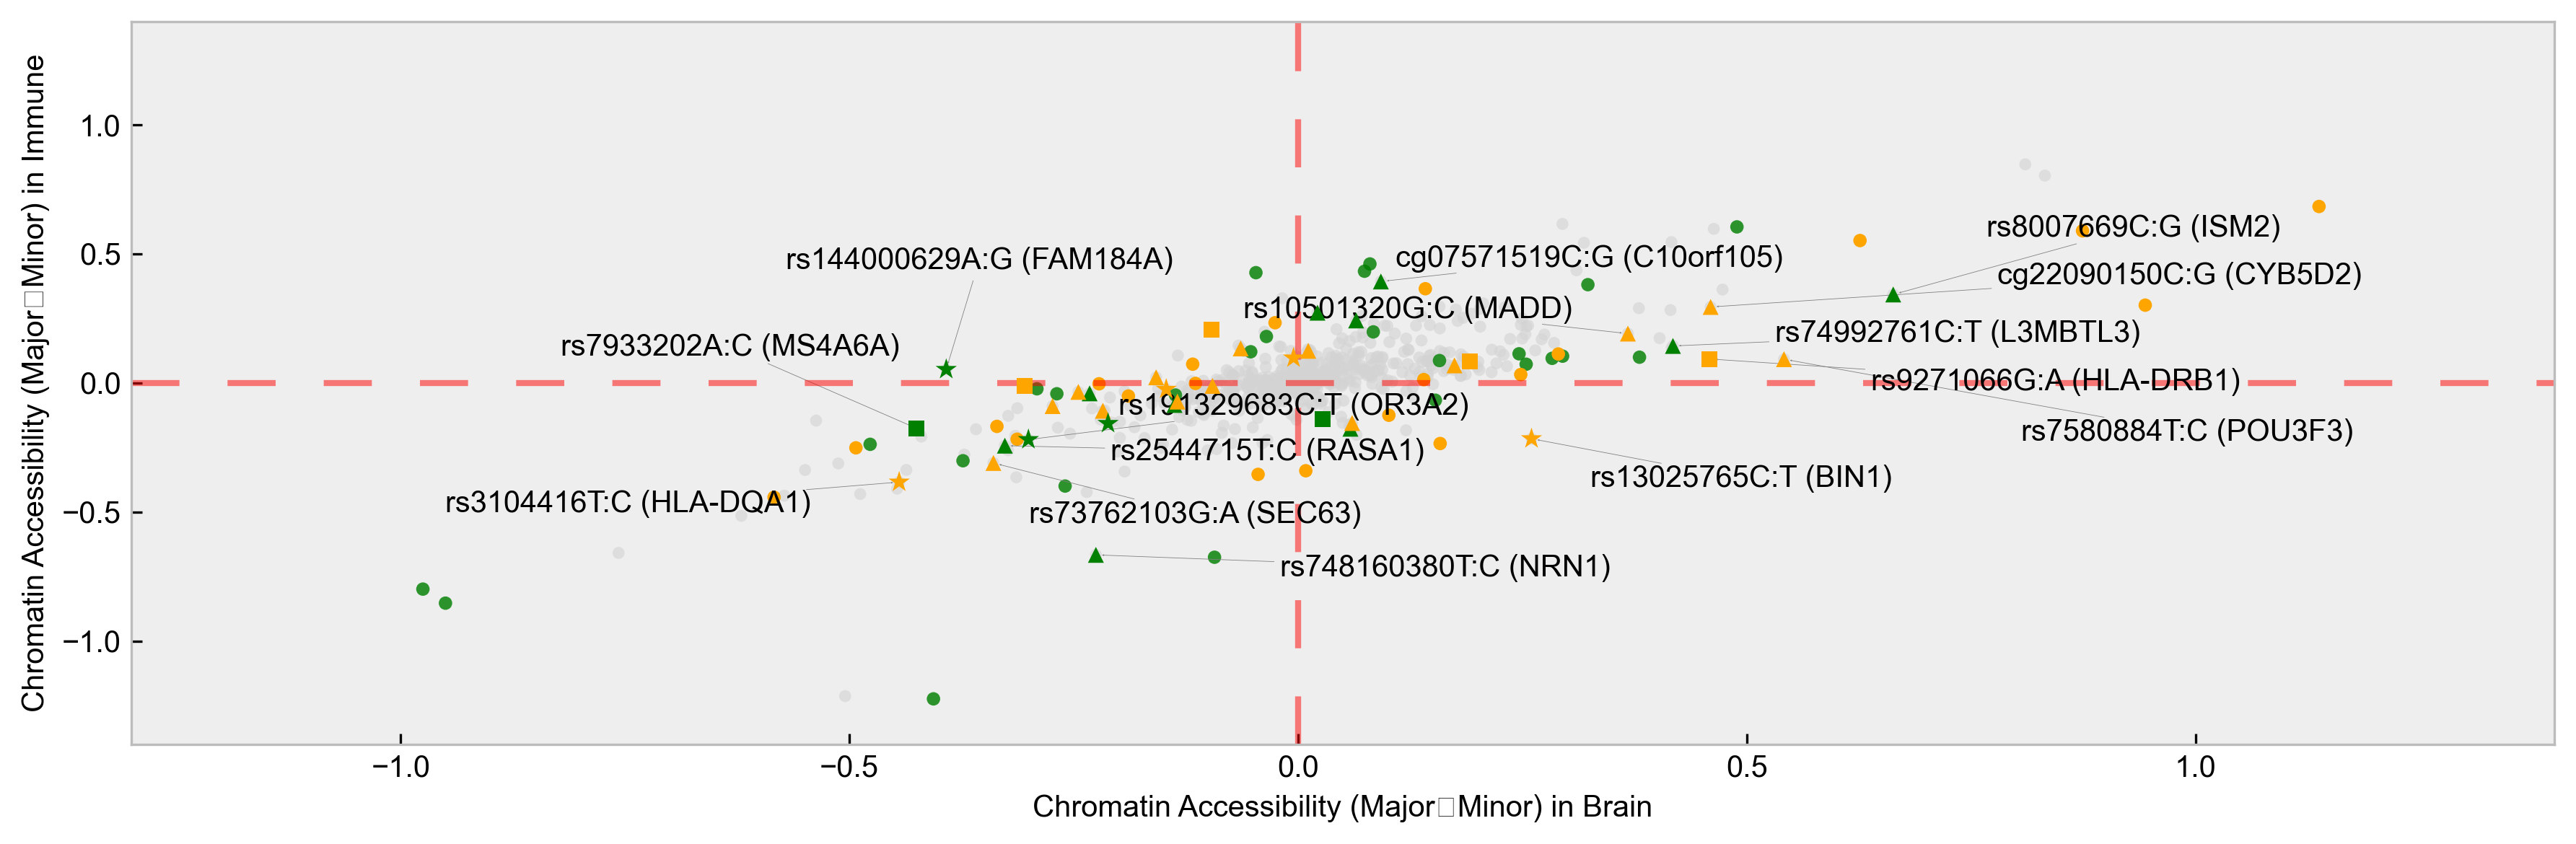

In [61]:
# ──────────────────────────────────────────────────────────────
#  Imports
# ──────────────────────────────────────────────────────────────
from adjustText import adjust_text
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import matplotlib as mpl
mpl.rcParams.update({
    'pdf.fonttype': 42,   # embed TrueType fonts → Illustrator‑editable
    'ps.fonttype': 42,    # same for EPS/PS
    'svg.fonttype': 'none',   # keep text as <text> elements in SVG
    'font.family': 'Arial',   # use a font installed on your machine
})

# ──────────────────────────────────────────────────────────────
# 0  Load data  (original paths & filters)
# ──────────────────────────────────────────────────────────────
df_mpra_thp1 = pd.read_csv(
    '/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/'
    '20240813_allele_only/20240813_comparative_THP1Macrophage_alleleOnly.csv',
    index_col=0
).query('fdr <= 0.05 and abs(logFC) >= 0.00')

df_mpra_brain = pd.read_csv(
    '/media/zihengc/T7/mpra3_lib_analysis/allele_differences_withoutcontrol/'
    '20240813_allele_only/20240616_comparative_BrainR1R2merged20240404_alleleOnly.csv',
    index_col=0
).query('fdr <= 0.05 and abs(logFC) >= 0.00')

df_cluster = pd.read_csv(
    '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/'
    'normalized_majorminor_diff.csv',
    index_col=0
)

df_cluster = pd.merge(
    df_cluster,
    df_haploreg[['rsid_protein_coding_gene', 'rsID']],
    left_index=True, right_index=True
).drop_duplicates('rsID')

df_merged = df_cluster.merge(
    results_df[['Adj_PValue', 'Significant']],
    left_index=True, right_index=True
)

# preserve for downstream use (matches your original variable name)
significant = df_merged[df_merged['Significant']]

# optional save (unchanged)
df_merged[df_merged['Significant']].to_csv(
    '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/'
    'immune_brain_normalized_diff_significant.csv'
)

df_normalized_logfc_immune_brain = pd.read_csv(
    '/media/zihengc/T7/THP1_machinelearning/prediction/allele_differences_genomic_mpra/'
    'immune_brain_normalized_logfc_significant.csv',
    index_col=0
)
df_normalized_logfc_immune_brain_significant = \
    df_normalized_logfc_immune_brain.query('Adj_PValue <= 0.05')

significant_points_rsid = df_merged[df_merged['Significant']]['rsid_protein_coding_gene']
significant_overlap = significant_points_rsid[
    significant_points_rsid.isin(
        df_normalized_logfc_immune_brain_significant['rsid_protein_coding_gene']
    )
]

# ──────────────────────────────────────────────────────────────
# 1  Prepare indices and means
# ──────────────────────────────────────────────────────────────
significant_points_index = df_merged.index[df_merged['Significant']]

x_mean = df_merged.iloc[:, 0:4].mean(axis=1)   # Brain
y_mean = df_merged.iloc[:, 4:10].mean(axis=1)  # Immune

# MPRA membership for shapes
both_mpra   = df_mpra_thp1.index.intersection(df_mpra_brain.index)
thp1_only   = df_mpra_thp1.index.difference(df_mpra_brain.index)
brain_only  = df_mpra_brain.index.difference(df_mpra_thp1.index)

mpra_sig_idx = (
    both_mpra.union(thp1_only).union(brain_only)   # fixed union
    .intersection(significant_points_index)        # also accessibility-sig
)

# ──────────────────────────────────────────────────────────────
# 2  Plot
# ──────────────────────────────────────────────────────────────
plt.figure(figsize=(12, 4), dpi=300)
fig.patch.set_alpha(0)
ax.set_facecolor("none")
# (a) Non‑significant background
plt.scatter(
    x_mean, y_mean,
    c='lightgrey', s=16, alpha=0.6,
    label='Non-significant', edgecolor='none'
)

# (b) Accessibility‑significant (green circles) – exclude MPRA‑sig
green_idx = (
    significant_points_index
    .difference(significant_overlap.index)    # not logFC‑sig
    .difference(mpra_sig_idx)                 # not MPRA‑sig
)
plt.scatter(
    x_mean[green_idx], y_mean[green_idx],
    c='green', s=20, alpha=0.8,
    label='Significant Accessibility Differences', edgecolor='none'
)

# (c) Accessibility + logFC (orange circles) – exclude MPRA‑sig
orange_idx = significant_overlap.index.difference(mpra_sig_idx)
plt.scatter(
    x_mean[orange_idx], y_mean[orange_idx],
    c='orange', s=20, alpha=1.0,
    label='Significant Accessibility Differences and log2(Fold Change)',
    edgecolor='none'
)

# ──────────────────────────────────────────────────────────────
# 3  Overlay larger shapes for MPRA significance
# ──────────────────────────────────────────────────────────────
# ──────────────────────────────────────────────────────────────
# 3  Overlay larger shapes for MPRA significance  (stars bigger)
# ──────────────────────────────────────────────────────────────
def _overlay(idx_set, marker_shape, size=28):
    idx_set = idx_set.intersection(significant_points_index)
    if idx_set.empty:
        return
    g = idx_set.difference(significant_overlap.index)   # colour green
    o = idx_set.intersection(significant_overlap.index) # colour orange
    if not g.empty:
        plt.scatter(
            x_mean[g], y_mean[g],
            c='green', marker=marker_shape, s=size,
            edgecolor='none', alpha=1, zorder=5, label='_nolegend_'
        )
    if not o.empty:
        plt.scatter(
            x_mean[o], y_mean[o],
            c='orange', marker=marker_shape, s=size,
            edgecolor='none', alpha=1, zorder=5, label='_nolegend_'
        )

_overlay(thp1_only,  '^', 28)   # triangle ▲ (size unchanged)
_overlay(brain_only, 's', 28)   # square   ■ (size unchanged)
_overlay(both_mpra,  '*', 55)   # star     ★ <BIGGER>


# ──────────────────────────────────────────────────────────────
# 4  Label only the shape‑marked points, but cap how many appear
#     ----------------------------------------------------------
#     • n_labels sets the maximum number of labels you want.
#     • They’re ranked by |x| + |y| (furthest from origin first),
#       so you see the most “extreme” ones.
# ──────────────────────────────────────────────────────────────
n_labels = 15             # ← change this to whatever cap you prefer

shape_idx = mpra_sig_idx                     # all ▲ ■ ★ indices
if shape_idx.size > n_labels:
    # sort by combined magnitude and take the top `n_labels`
    to_label = (x_mean.abs() + y_mean.abs()).loc[shape_idx] \
                                                .nlargest(n_labels).index
else:
    to_label = shape_idx

texts = [
    plt.text(
        x_mean[idx], y_mean[idx],
        df_merged.loc[idx, 'rsid_protein_coding_gene'],
        fontsize=10, color='black'
    )
    for idx in to_label
]

adjust_text(
    texts,
    
    arrowprops=dict(arrowstyle='->', color='gray', lw=0.2)
)


# ──────────────────────────────────────────────────────────────
# 5  Cosmetics (unchanged)
# ──────────────────────────────────────────────────────────────
#plt.grid(color='lightgray', linestyle='--', linewidth=0.1)
plt.grid(False)
plt.axvline(0, color='red', linestyle='--', alpha=0.5, dashes=(8, 8))
plt.axhline(0, color='red', linestyle='--', alpha=0.5, dashes=(8, 8))

plt.xlim(-1.3, 1.4)
plt.ylim(-1.4, 1.4)

plt.xlabel('Chromatin Accessibility (Major‑Minor) in Brain',  fontsize=10)
plt.ylabel('Chromatin Accessibility (Major‑Minor) in Immune', fontsize=10)
#plt.title('Immune vs Brain', fontsize=12, weight='bold')

#plt.legend(frameon=True, fontsize=8)
plt.tight_layout()
plt.savefig('scatter_plot_NeuronsTHP1_labeled_adjusted3.pdf',
            dpi=300, bbox_inches='tight',transparent=True)
plt.show()
